# Tema 5 - Transistores de Efecto de Campo FET

**Fundamentos de Electrónica - 2º GIERM**

---

## Objetivos de aprendizaje

- Comprender la estructura y funcionamiento de los transistores MOSFET y JFET
- Dominar las ecuaciones de corriente en las tres zonas de funcionamiento (corte, óhmica, saturación)
- Interpretar las curvas características de salida y de saturación
- Diferenciar entre los 4 tipos de MOSFET y los 2 de JFET
- Resolver circuitos de polarización para MOSFET y JFET con metodología sistemática
- Conocer la ecuación de Shockley y su relación con las ecuaciones del MOSFET

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'
COLOR_RECTA = '#cb181d'
COLOR_PUNTO = '#238b45'
COLOR_N = '#a6cee3'
COLOR_P = '#b2df8a'
COLOR_OXIDO = '#fdae6b'
COLOR_METAL = '#bdbdbd'

print('Configuración lista.')

Configuración lista.


---
## 1. Introducción: FET vs BJT

Los transistores de efecto de campo (**FET**, *Field Effect Transistor*) son dispositivos **unipolares**: la corriente está formada por un solo tipo de portador (electrones o huecos). A diferencia del BJT (bipolar), el FET es controlado por **tensión**, no por corriente.

### Diferencias fundamentales

| Característica | BJT | FET |
|---|---|---|
| Control | Por corriente ($I_B$) | Por tensión ($V_{GS}$) |
| Corriente de entrada | $I_B > 0$ | $I_G = 0$ (idealmente) |
| Impedancia de entrada | Media-baja | Muy alta ($\sim M\Omega$) |
| Tipo | Bipolar | Unipolar |
| Terminales | Base, Colector, Emisor | Puerta (G), Drenador (D), Fuente (S) |
| Ecuación en activa/sat. | $I_C = \beta \cdot I_B$ (lineal) | $I_D = \frac{K}{2}(V_{GS}-V_T)^2$ (cuadrática) |

### Tipos de FET

- **MOSFET** (*Metal-Oxide-Semiconductor FET*): el más usado en electrónica digital (CMOS)
  - Canal N / Canal P
  - Enriquecimiento / Empobrecimiento
- **JFET** (*Junction FET*): más simple, usado en amplificadores de bajo ruido
  - Canal N / Canal P

**Ventajas del FET**: alta integración, bajo consumo, fabricación barata.

---
## 2. El transistor MOSFET

### 2.1 Estructura

El MOSFET tiene **4 terminales**: Puerta (G), Drenador (D), Fuente (S) y Sustrato (B). Las siglas MOS hacen referencia a la estructura Metal-Óxido-Semiconductor.

- **Sustrato**: semiconductor tipo p (canal n) o tipo n (canal p)
- **Drenador y Fuente**: pozos de material complementario al sustrato, fuertemente dopados
- **Puerta**: capa de metal sobre óxido de silicio (SiO$_2$) - actúa como condensador
- **Canal**: se forma por **inversión** debajo del óxido cuando $V_{GS} > V_T$

**Propiedad fundamental**: la corriente de puerta es siempre nula ($I_G = 0$) porque el óxido es aislante. La corriente de sustrato también es nula ($I_B = 0$) porque las uniones pn están en inversa.

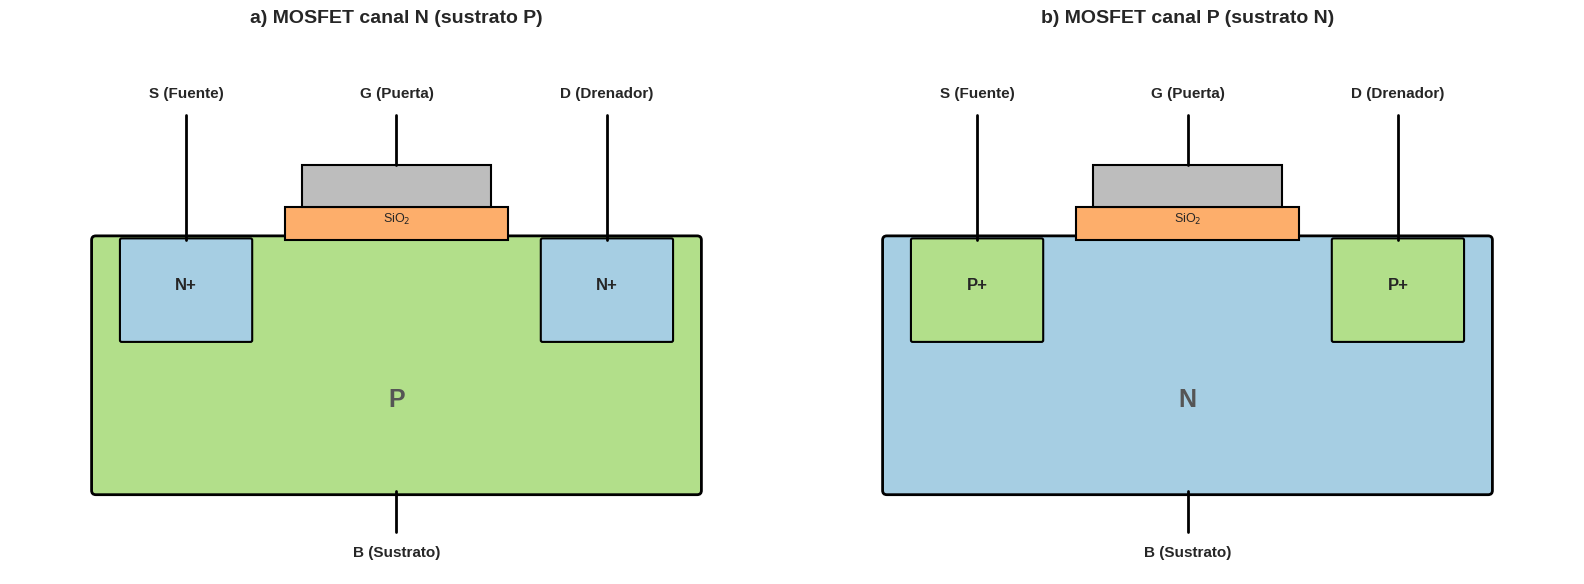

In [2]:
# Estructura MOSFET canal N y canal P
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def dibujar_mosfet_estructura(ax, tipo, titulo):
    ax.set_xlim(-1, 8); ax.set_ylim(-1, 5.5); ax.axis('off')
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    if tipo == 'N':
        col_sust, col_pozo, lbl_sust, lbl_pozo = COLOR_P, COLOR_N, 'P', 'N+'
    else:
        col_sust, col_pozo, lbl_sust, lbl_pozo = COLOR_N, COLOR_P, 'N', 'P+'
    # Sustrato
    ax.add_patch(FancyBboxPatch((0,0), 7, 3, boxstyle='round,pad=0.05',
                 facecolor=col_sust, edgecolor='black', lw=2))
    ax.text(3.5, 1.0, lbl_sust, fontsize=18, ha='center', fontweight='bold', color='#555')
    # Pozos
    for x, lbl in [(0.3, 'S'), (5.2, 'D')]:
        ax.add_patch(FancyBboxPatch((x, 1.8), 1.5, 1.2, boxstyle='round,pad=0.02',
                     facecolor=col_pozo, edgecolor='black', lw=1.5))
        ax.text(x+0.75, 2.4, lbl_pozo, fontsize=12, ha='center', fontweight='bold')
    # Óxido
    ax.add_patch(FancyBboxPatch((2.2, 3), 2.6, 0.4, boxstyle='square,pad=0',
                 facecolor=COLOR_OXIDO, edgecolor='black', lw=1.5))
    ax.text(3.5, 3.2, r'SiO$_2$', fontsize=9, ha='center')
    # Metal (puerta)
    ax.add_patch(FancyBboxPatch((2.4, 3.4), 2.2, 0.5, boxstyle='square,pad=0',
                 facecolor=COLOR_METAL, edgecolor='black', lw=1.5))
    # Terminales
    ax.plot([1.05, 1.05], [3, 4.5], 'k-', lw=2)
    ax.text(1.05, 4.7, 'S (Fuente)', fontsize=11, ha='center', fontweight='bold')
    ax.plot([3.5, 3.5], [3.9, 4.5], 'k-', lw=2)
    ax.text(3.5, 4.7, 'G (Puerta)', fontsize=11, ha='center', fontweight='bold')
    ax.plot([5.95, 5.95], [3, 4.5], 'k-', lw=2)
    ax.text(5.95, 4.7, 'D (Drenador)', fontsize=11, ha='center', fontweight='bold')
    ax.plot([3.5, 3.5], [0, -0.5], 'k-', lw=2)
    ax.text(3.5, -0.8, 'B (Sustrato)', fontsize=11, ha='center', fontweight='bold')

dibujar_mosfet_estructura(axes[0], 'N', 'a) MOSFET canal N (sustrato P)')
dibujar_mosfet_estructura(axes[1], 'P', 'b) MOSFET canal P (sustrato N)')
plt.tight_layout(); plt.show()

### 2.2 El MOSFET como interruptor controlado

El MOSFET funciona como un **interruptor controlado por tensión**:

- Si $V_{GS} < V_T$ (tensión umbral): **no hay canal** $\to$ $I_D = 0$ $\to$ **interruptor abierto**
- Si $V_{GS} > V_T$: **se forma un canal conductor** $\to$ $I_D > 0$ $\to$ **interruptor cerrado**

La tensión umbral $V_T$ es el valor mínimo de $V_{GS}$ necesario para crear el canal. Su valor típico está entre 1 y 3 V para transistores de enriquecimiento.

**Dos hechos fundamentales** (siempre se cumplen):

$$I_G = 0 \qquad I_B = 0$$

Esto significa que **toda la corriente que entra por el drenador sale por la fuente**: $I_D = I_S$.

---
## 3. Formulario completo del MOSFET

### 3.1 Ecuaciones simplificadas del MOSFET de canal N

| Zona | Condición | Ecuación de $I_D$ |
|------|-----------|-------------------|
| **Corte** | $V_{GS} \leq V_T$ | $I_D = 0$ |
| **Óhmica** | $V_{GS} > V_T$ y $V_{DS} < V_{GS} - V_T$ | $I_D = K_n \left[(V_{GS}-V_T) \cdot V_{DS} - \dfrac{V_{DS}^2}{2}\right]$ |
| **Saturación** | $V_{GS} > V_T$ y $V_{DS} \geq V_{GS} - V_T$ | $I_D = \dfrac{K_n}{2} (V_{GS} - V_T)^2$ |

### 3.2 Ecuaciones completas (con modulación de canal y efecto sustrato)

En **saturación** con modulación de longitud de canal:

$$\boxed{I_D = \frac{K_n}{2} (V_{GS} - V_T)^2 (1 + \lambda V_{DS})}$$

Tensión umbral con efecto sustrato ($V_{SB} \neq 0$):

$$V_T = V_{T0} + \gamma \left(\sqrt{\phi_{H0} + V_{SB}} - \sqrt{\phi_{H0}}\right)$$

### 3.3 Ecuaciones del MOSFET de canal P (con referencia $V_{SG}$, $V_{SD}$)

| Zona | Condición | Ecuación de $I_D$ |
|------|-----------|-------------------|
| **Corte** | $V_{SG} \leq V_T$ | $I_D = 0$ |
| **Óhmica** | $V_{SG} > V_T$ y $V_{SD} < V_{SG} - V_T$ | $I_D = K_p \left[(V_{SG}-V_T) \cdot V_{SD} - \dfrac{V_{SD}^2}{2}\right]$ |
| **Saturación** | $V_{SG} > V_T$ y $V_{SD} \geq V_{SG} - V_T$ | $I_D = \dfrac{K_p}{2} (V_{SG} - V_T)^2$ |

### 3.4 Parámetros

| Parámetro | Descripción |
|-----------|-------------|
| $K_n = \mu_n C_{OX} \dfrac{W}{L}$ | Parámetro de transconductancia (canal N) |
| $K_p = \mu_p C_{OX} \dfrac{W}{L}$ | Parámetro de transconductancia (canal P) |
| $V_T$ | Tensión umbral (positiva enriq. N, negativa empob. N) |
| $\lambda$ | Parámetro de modulación de longitud de canal |
| $W/L$ | Relación de aspecto (anchura/longitud del canal) |
| $\mu_n$, $\mu_p$ | Movilidad de electrones y huecos |
| $C_{OX}$ | Capacidad del óxido de puerta |
| $\gamma$ | Parámetro de efecto sustrato |
| $\phi_{H0}$ | Potencial de inversión fuerte |

### 3.5 MOSFET como resistencia variable (zona óhmica, $V_{DS}$ pequeña)

$$I_D \approx K_n (V_{GS} - V_T) \cdot V_{DS} = \frac{V_{DS}}{R_{DS}}$$

$$\boxed{R_{DS} = \frac{1}{K_n (V_{GS} - V_T)}}$$

### 3.6 Recta de carga y mallas de polarización

$$V_{DS} = V_{CC} - R_D \cdot I_D \qquad \text{(malla de drenador)}$$

$$V_{GS} = V_G - R_S \cdot I_D \qquad \text{(con } R_S \text{ en fuente)}$$

---
## 4. Zonas de funcionamiento del MOSFET

El MOSFET de canal N tiene **tres zonas** de funcionamiento, definidas por las tensiones $V_{GS}$ y $V_{DS}$:

### Corte ($V_{GS} \leq V_T$)
- No existe canal conductor $\to$ $I_D = 0$
- El transistor está **apagado**
- Funciona como **circuito abierto** entre D y S

### Zona Óhmica o Lineal ($V_{GS} > V_T$ y $V_{DS} < V_{GS} - V_T$)
- El canal existe y **no está estrangulado**
- $I_D$ depende tanto de $V_{GS}$ como de $V_{DS}$
- Para $V_{DS}$ pequeños: comportamiento de **resistencia** ($I_D \propto V_{DS}$)
- Frontera con saturación en $V_{DS} = V_{GS} - V_T$

### Saturación ($V_{GS} > V_T$ y $V_{DS} \geq V_{GS} - V_T$)
- El canal está **estrangulado** cerca del drenador
- $I_D$ depende **solo de $V_{GS}$** (idealmente): $I_D = \frac{K_n}{2}(V_{GS}-V_T)^2$
- Funciona como **fuente de corriente controlada por tensión**
- Es la zona de operación normal para amplificadores

**Diferencia clave con el BJT**: en el BJT "saturación" = transistor completamente encendido (interruptor cerrado). En el MOSFET "saturación" = zona de amplificación (fuente de corriente). ¡No confundir!

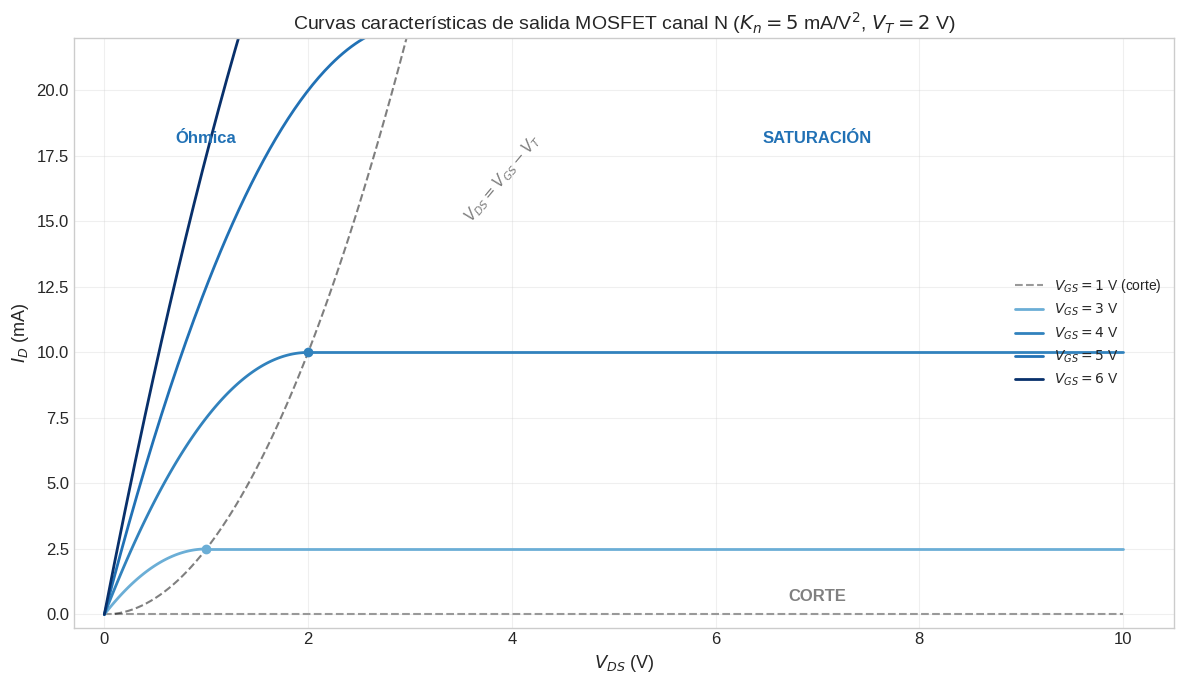

In [3]:
# Curvas características de salida MOSFET canal N
fig, ax = plt.subplots(figsize=(12, 7))
Kn = 5e-3  # 5 mA/V^2
VT = 2.0   # V
VDS = np.linspace(0, 10, 500)
VGS_vals = [1, 3, 4, 5, 6]
colores = ['#999999', '#6baed6', '#3182bd', '#2171b5', '#08306b']

for vgs, color in zip(VGS_vals, colores):
    if vgs <= VT:
        ax.plot(VDS, np.zeros_like(VDS), color=color, lw=1.5, ls='--',
                label=rf'$V_{{GS}} = {vgs}$ V (corte)')
    else:
        vds_sat = vgs - VT
        # Zona óhmica
        mask_ohm = VDS < vds_sat
        id_ohm = Kn * ((vgs - VT) * VDS[mask_ohm] - VDS[mask_ohm]**2 / 2)
        ax.plot(VDS[mask_ohm], id_ohm * 1e3, color=color, lw=2)
        # Zona saturación
        mask_sat = VDS >= vds_sat
        id_sat = Kn / 2 * (vgs - VT)**2 * np.ones_like(VDS[mask_sat])
        ax.plot(VDS[mask_sat], id_sat * 1e3, color=color, lw=2,
                label=rf'$V_{{GS}} = {vgs}$ V')
        # Punto de transición
        ax.plot(vds_sat, Kn/2*(vgs-VT)**2*1e3, 'o', color=color, ms=6, zorder=5)

# Frontera óhmica-saturación
vgs_front = np.linspace(VT+0.1, 6.5, 100)
vds_front = vgs_front - VT
id_front = Kn / 2 * (vgs_front - VT)**2
ax.plot(vds_front, id_front * 1e3, 'k--', lw=1.5, alpha=0.5)
ax.text(3.5, 15, r'$V_{DS} = V_{GS} - V_T$', fontsize=11, rotation=50, alpha=0.6)

ax.text(1, 18, r'Óhmica', fontsize=12, fontweight='bold', color=COLOR_PRINCIPAL, ha='center')
ax.text(7, 18, 'SATURACIÓN', fontsize=12, fontweight='bold', color=COLOR_PRINCIPAL, ha='center')
ax.text(7, 0.5, 'CORTE', fontsize=12, fontweight='bold', color='gray', ha='center')

ax.set_xlabel(r'$V_{DS}$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(r'Curvas características de salida MOSFET canal N ($K_n = 5$ mA/V$^2$, $V_T = 2$ V)')
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.5, 22)
ax.legend(fontsize=10, loc='center right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

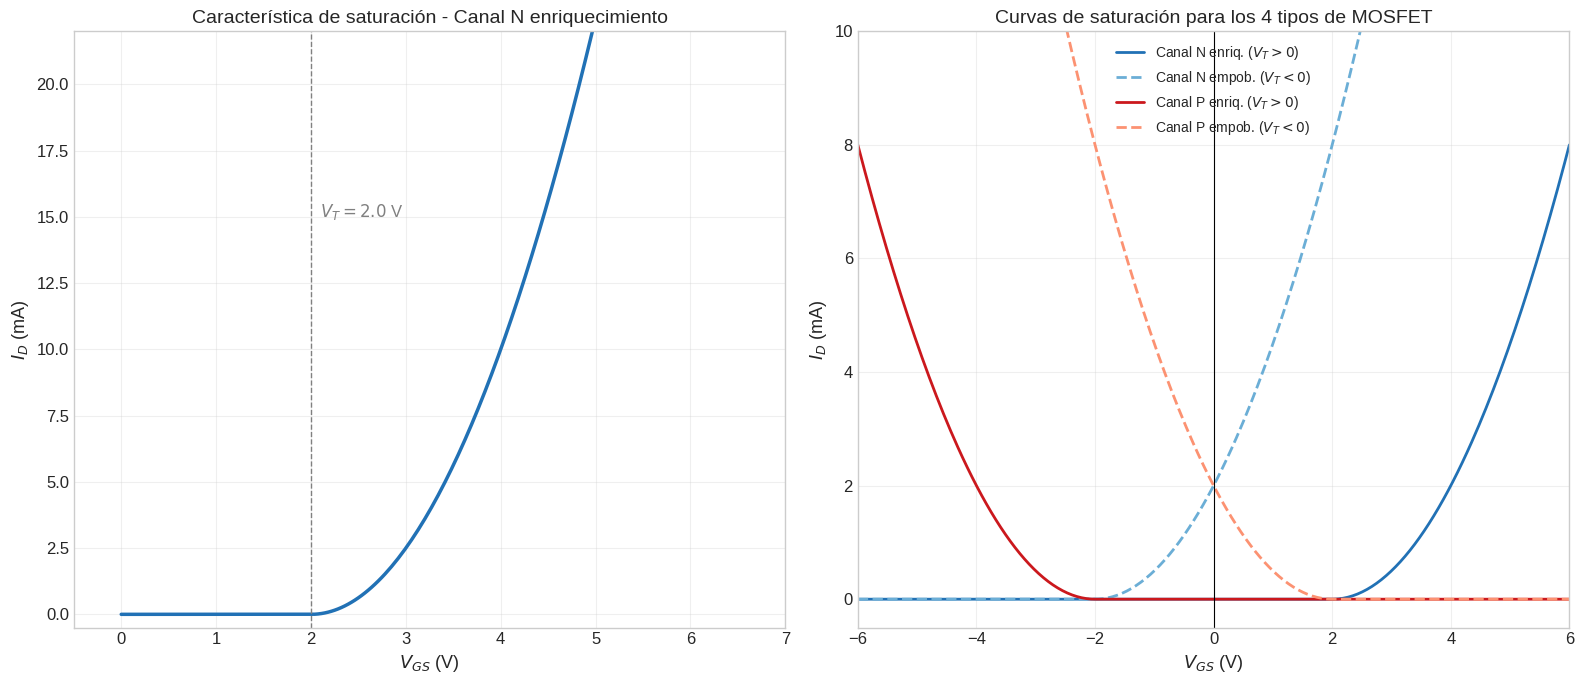

In [4]:
# Característica de saturación: I_D vs V_GS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

Kn = 5e-3; VT = 2.0
VGS = np.linspace(0, 7, 200)
ID_sat = np.where(VGS > VT, Kn/2 * (VGS - VT)**2, 0)

# Canal N enriquecimiento
ax = axes[0]
ax.plot(VGS, ID_sat * 1e3, color=COLOR_PRINCIPAL, lw=2.5)
ax.axvline(x=VT, color='gray', ls='--', lw=1)
ax.text(VT+0.1, 15, rf'$V_T = {VT}$ V', fontsize=12, color='gray')
ax.fill_between(VGS[VGS<=VT], 0, 0, alpha=0.1, color='lightblue')
ax.set_xlabel(r'$V_{GS}$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Característica de saturación - Canal N enriquecimiento')
ax.set_xlim(-0.5, 7); ax.set_ylim(-0.5, 22)
ax.grid(True, alpha=0.3)

# Anotación
ax.annotate(rf'$I_D = \frac{{K_n}}{{2}}(V_{{GS}}-V_T)^2$',
            xy=(5, Kn/2*(5-VT)**2*1e3), xytext=(3, 18),
            fontsize=13, color=COLOR_PRINCIPAL,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PRINCIPAL))

# Los 4 tipos de MOSFET (curvas de saturación)
ax = axes[1]
ax.set_title('Curvas de saturación para los 4 tipos de MOSFET')
vgs_range = np.linspace(-6, 6, 300)
# Canal N enriquecimiento (VT = +2)
id_ne = np.where(vgs_range > 2, 0.5*(vgs_range-2)**2, 0)
ax.plot(vgs_range, id_ne, color='#2171b5', lw=2, label='Canal N enriq. ($V_T>0$)')
# Canal N empobrecimiento (VT = -2)
id_nd = np.where(vgs_range > -2, 0.5*(vgs_range+2)**2, 0)
ax.plot(vgs_range, id_nd, color='#6baed6', lw=2, ls='--', label='Canal N empob. ($V_T<0$)')
# Canal P enriquecimiento (VT = +2, con |VGS|)
vsg = -vgs_range
id_pe = np.where(vsg > 2, 0.5*(vsg-2)**2, 0)
ax.plot(vgs_range, id_pe, color='#cb181d', lw=2, label='Canal P enriq. ($V_T>0$)')
# Canal P empobrecimiento (VT = -2, con |VGS|)
id_pd = np.where(vsg > -2, 0.5*(vsg+2)**2, 0)
ax.plot(vgs_range, id_pd, color='#fc9272', lw=2, ls='--', label='Canal P empob. ($V_T<0$)')

ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlabel(r'$V_{GS}$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-6, 6); ax.set_ylim(-0.5, 10)
plt.tight_layout(); plt.show()

---
## 5. Símbolos eléctricos del MOSFET

Existen **4 tipos** de MOSFET según el tipo de canal y el modo de operación:

| Tipo | Canal | $V_T$ | Canal a $V_{GS}=0$ |
|------|-------|-------|---------------------|
| Canal N **enriquecimiento** | N | $V_T > 0$ | No existe (necesita $V_{GS} > V_T$) |
| Canal N **empobrecimiento** | N | $V_T < 0$ | Ya existe |
| Canal P **enriquecimiento** | P | $V_T > 0$ (con $V_{SG}$) | No existe |
| Canal P **empobrecimiento** | P | $V_T < 0$ (con $V_{SG}$) | Ya existe |

**Cómo distinguirlos en el símbolo:**
- **Enriquecimiento**: canal dibujado con **línea discontinua** (no existe a $V_{GS}=0$)
- **Empobrecimiento**: canal dibujado con **línea continua** (ya existe)
- **Canal N**: flecha del sustrato **apunta hacia el canal** (hacia N)
- **Canal P**: flecha del sustrato **sale del canal** (sale de P)

En transistores discretos (3 terminales), fuente y sustrato están cortocircuitados internamente.

---
## 6. Metodología de resolución para MOSFET

La resolución de circuitos MOSFET sigue una metodología análoga a la del BJT, pero con diferencias importantes:

### Paso 1: Fijar referencias
$V_{GS}$, $V_{DS}$ y $I_D$ para canal N. $V_{SG}$, $V_{SD}$ y $I_D$ para canal P.

### Paso 2: Suponer un estado
Normalmente se empieza suponiendo **saturación** (la zona más usada en amplificadores).

### Paso 3: Sustituir por el modelo
- **Saturación**: $I_D = \frac{K_n}{2}(V_{GS}-V_T)^2$, $I_G = 0$
- **Óhmica**: $I_D = K_n[(V_{GS}-V_T)V_{DS} - V_{DS}^2/2]$, $I_G = 0$
- **Corte**: $I_D = 0$, $I_G = 0$

### Paso 4: Resolver las ecuaciones
Como $I_G = 0$, la malla de puerta suele ser trivial. La ecuación de saturación es cuadrática.

### Paso 5: Verificar la hipótesis
- **Saturación**: comprobar $V_{DS} \geq V_{GS} - V_T$ y $V_{GS} > V_T$
- **Óhmica**: comprobar $V_{DS} < V_{GS} - V_T$ y $V_{GS} > V_T$
- **Corte**: comprobar $V_{GS} \leq V_T$

**Diferencia con el BJT**: en el MOSFET las ecuaciones son **cuadráticas** (no lineales), por lo que a menudo hay que resolver una ecuación de segundo grado.

---
## 7. Circuitos de polarización del MOSFET

A diferencia del BJT, la polarización del MOSFET se facilita por la ausencia de corriente de puerta ($I_G = 0$), pero las ecuaciones son más complejas (cuadráticas).

### 7.1 Tipo 1: Polarización básica (dos fuentes)

La red más sencilla: una fuente $V_i$ fija $V_{GS}$ y otra $V_{CC}$ fija $V_{DS}$.

Como $I_G = 0$: $V_{GS} = V_i$ directamente. La recta de carga es **vertical**: $V_{DS} = V_{CC}$.

$$I_D = \frac{K_n}{2}(V_i - V_T)^2 \qquad V_{DS} = V_{CC}$$

**Verificar saturación**: $V_{DS} = V_{CC} \geq V_{GS} - V_T = V_i - V_T$

#### Ejercicio resuelto: MOSFET polarización básica

**Datos:** $V_i = 4$ V, $V_{CC} = 10$ V, $K_n = 5$ mA/V$^2$, $V_T = 2$ V

**Paso 1-2:** Suponer saturación.

**Paso 3-4:** Como $I_G = 0$: $V_{GS} = V_i = 4$ V

$$I_D = \frac{K_n}{2}(V_{GS}-V_T)^2 = \frac{5 \times 10^{-3}}{2}(4-2)^2 = 10\;\text{mA}$$

$$V_{DS} = V_{CC} = 10\;\text{V}$$

**Paso 5:** $V_{DS} = 10$ V $\geq V_{GS} - V_T = 4 - 2 = 2$ V $\to$ **Saturación confirmada.**

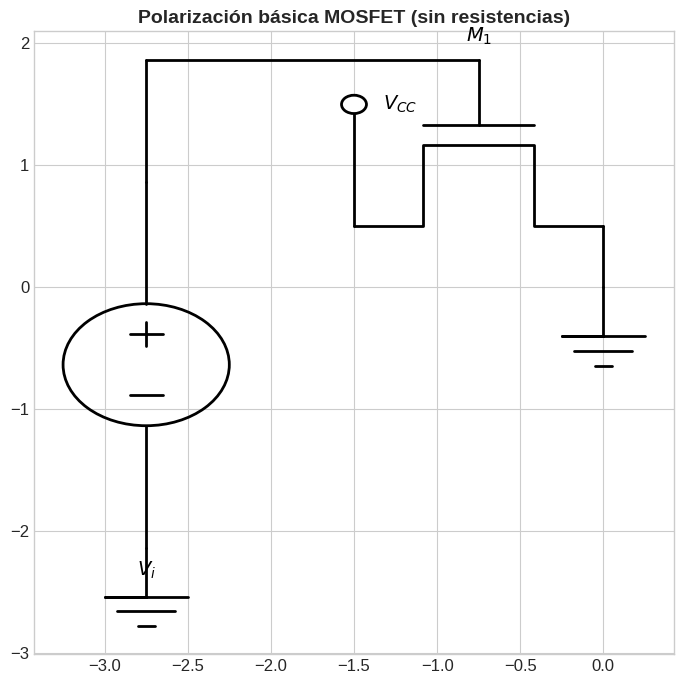

In [5]:
# Diagrama: MOSFET polarización básica (sin resistencias)
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Polarización básica MOSFET (sin resistencias)', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
nmos = elm.NFet(circle=True)
d += nmos.anchor('source').label(r'$M_1$', loc='right')
m = d.elements[-1]
# VCC al drenador
d += elm.Line().at(m.drain).up().length(1)
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
# Vi a la puerta
d += elm.Line().at(m.gate).left().length(2)
d += elm.Line().down().length(1)
d += elm.SourceV().down().label(r'$V_i$', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 7.2 Tipo 2: Polarización por retroalimentación ($R_G$ de D a G)

Drenador y puerta conectados a través de $R_G$. Como $I_G = 0$, la caída en $R_G$ es nula:

$$V_{GS} = V_{DS}$$

Combinando con la ecuación de saturación y la recta de carga:

$$I_D = \frac{K_n}{2}(V_{DS}-V_T)^2 \qquad V_{DS} = V_{CC} - R_D \cdot I_D$$

Esto produce una ecuación cuadrática en $V_{DS}$ que se resuelve sustituyendo.

#### Ejercicio resuelto: MOSFET retroalimentación

**Datos:** $V_{CC} = 10$ V, $R_D = 2$ k$\Omega$, $R_G = 1$ M$\Omega$, $K_n = 2$ mA/V$^2$, $V_T = 2$ V

**Paso 1-2:** Suponer saturación. Como $I_G = 0$: $V_{GS} = V_{DS}$

**Paso 3-4:** Sustituyendo $I_D$ en la recta de carga:

$$V_{DS} = V_{CC} - R_D \cdot \frac{K_n}{2}(V_{DS}-V_T)^2$$

$$V_{DS} = 10 - 2\text{k} \times \frac{2\times10^{-3}}{2}(V_{DS}-2)^2 = 10 - 2(V_{DS}-2)^2$$

$$V_{DS} = 10 - 2V_{DS}^2 + 8V_{DS} - 8$$

$$2V_{DS}^2 - 7V_{DS} - 2 = 0$$

$$V_{DS} = \frac{7 \pm \sqrt{49 + 16}}{4} = \frac{7 \pm \sqrt{65}}{4}$$

$$V_{DS} = \frac{7 + 8.06}{4} = 3.77\;\text{V} \quad \text{(tomamos la raíz positiva con sentido físico)}$$

$$I_D = \frac{K_n}{2}(3.77 - 2)^2 = 1 \times 10^{-3} \times 3.13 = 3.13\;\text{mA}$$

**Paso 5:** $V_{DS} = 3.77$ V $\geq V_{GS} - V_T = 3.77 - 2 = 1.77$ V $\to$ **Saturación confirmada.**

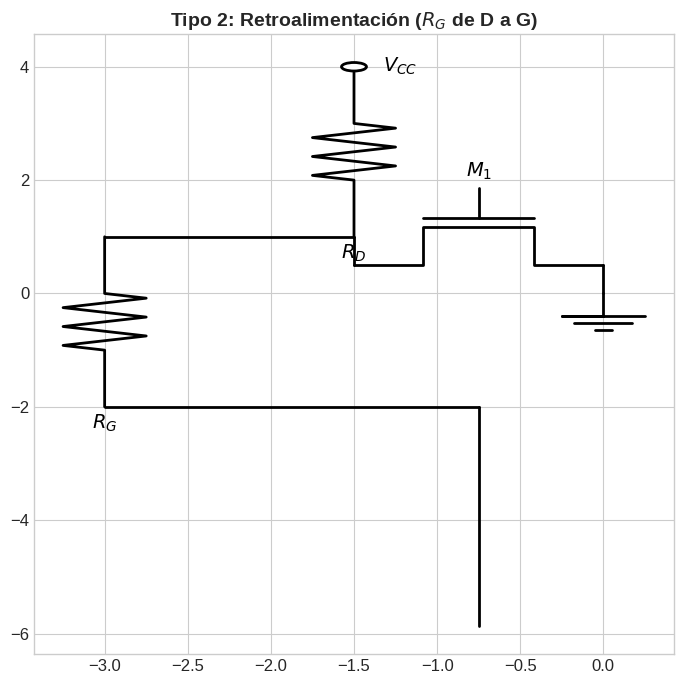

In [6]:
# Diagrama de polarización por retroalimentación
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 2: Retroalimentación ($R_G$ de D a G)', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
nmos = elm.NFet(circle=True)
d += nmos.anchor('source').label('$M_1$', loc='right')
m = d.elements[-1]
d += elm.Line().at(m.drain).up().length(0.5)
col_pt = d.here
d += elm.Resistor().up().label('$R_D$', loc='left')
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
# RG de drenador a puerta
d += elm.Line().at(col_pt).left().length(1.5)
d += elm.Resistor().down().label('$R_G$', loc='left')
d += elm.Line().right().tox(m.gate)
d += elm.Line().down().toy(m.gate)
d.draw()
plt.tight_layout(); plt.show()

### 7.3 Tipo 3: Polarización por divisor de tensión ($R_1 + R_2 + R_D + R_S$)

El circuito **más estable** para MOSFET. Un divisor $R_1$-$R_2$ fija $V_G$, y la $R_S$ proporciona estabilización.

Como $I_G = 0$, el divisor no tiene carga:

$$V_G = \frac{R_1}{R_1 + R_2} \cdot V_{CC}$$

La tensión puerta-fuente:

$$V_{GS} = V_G - R_S \cdot I_D$$

Combinando con la ecuación de saturación ($I_D = \frac{K_n}{2}(V_{GS}-V_T)^2$) se obtiene una **ecuación cuadrática** en $I_D$ o en $V_{GS}$.

**Cómo afectan los parámetros:**
- **$R_1 / R_2$** fijan $V_G$: al aumentar $R_1/(R_1+R_2)$, $V_G$ sube $\to$ $V_{GS}$ sube $\to$ $I_D$ aumenta
- **$R_S$** estabiliza: si $I_D$ sube $\to$ $V_S = R_S \cdot I_D$ sube $\to$ $V_{GS}$ baja $\to$ $I_D$ se corrige
- **$R_D$** solo afecta a $V_{DS}$: mayor $R_D$ $\to$ menor $V_{DS}$
- A diferencia del BJT, **no necesitamos Thévenin** porque $I_G = 0$ (no hay carga en el divisor)

#### Ejercicio resuelto: MOSFET divisor de tensión

**Datos:** $V_{CC} = 12$ V, $R_1 = 200$ k$\Omega$ (abajo), $R_2 = 400$ k$\Omega$ (arriba), $R_D = 2$ k$\Omega$, $R_S = 1$ k$\Omega$, $K_n = 4$ mA/V$^2$, $V_T = 1.5$ V

**Paso 1:** Tensión de puerta (divisor sin carga porque $I_G = 0$):

$$V_G = \frac{R_1}{R_1 + R_2} \cdot V_{CC} = \frac{200}{200+400} \times 12 = 4\;\text{V}$$

**Paso 2:** Suponer saturación

**Paso 3-4:** $V_{GS} = V_G - R_S \cdot I_D = 4 - 1\text{k} \cdot I_D$

Sustituyendo en la ecuación de saturación:

$$I_D = \frac{K_n}{2}(V_{GS}-V_T)^2 = \frac{4 \times 10^{-3}}{2}(4 - 10^3 I_D - 1.5)^2 = 2 \times 10^{-3}(2.5 - 10^3 I_D)^2$$

Sea $x = I_D$ en mA:

$$x = 2(2.5 - x)^2 = 2(6.25 - 5x + x^2) = 12.5 - 10x + 2x^2$$

$$2x^2 - 11x + 12.5 = 0$$

$$x = \frac{11 \pm \sqrt{121 - 100}}{4} = \frac{11 \pm \sqrt{21}}{4} = \frac{11 \pm 4.58}{4}$$

$$x_1 = 3.90\;\text{mA} \qquad x_2 = 1.60\;\text{mA}$$

Verificamos cuál está en saturación. Para $I_D = 1.60$ mA:

$$V_{GS} = 4 - 1\text{k} \times 1.60 = 2.40\;\text{V}$$

$$V_{DS} = V_{CC} - (R_D + R_S) \cdot I_D = 12 - 3\text{k} \times 1.60 = 7.20\;\text{V}$$

$$V_{DS} = 7.20 \geq V_{GS} - V_T = 2.40 - 1.5 = 0.90\;\text{V} \to \textbf{Saturación OK}$$

Para $I_D = 3.90$ mA:

$$V_{GS} = 4 - 3.90 = 0.10\;\text{V} < V_T = 1.5\;\text{V} \to \text{Corte (descartada)}$$

**Resultado:** $I_D = 1.60$ mA, $V_{GS} = 2.40$ V, $V_{DS} = 7.20$ V.

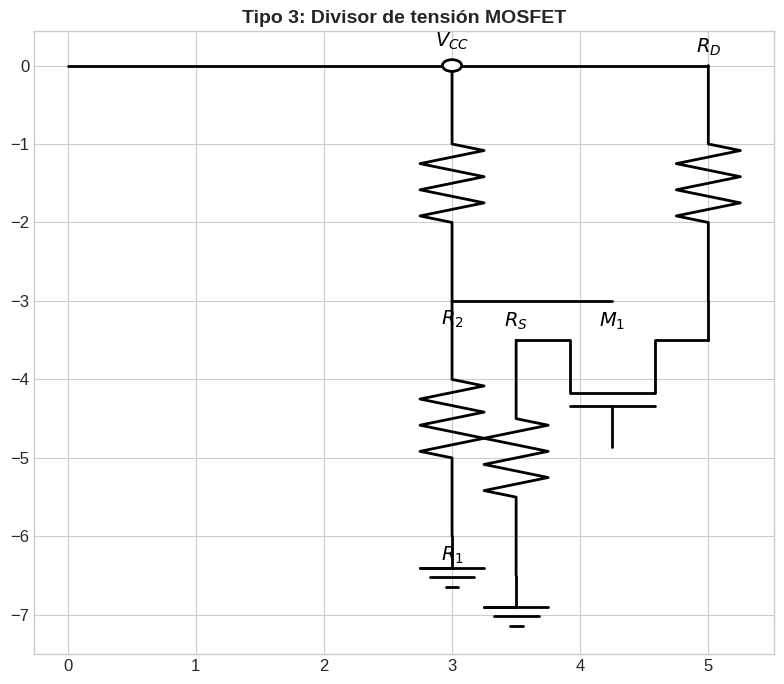

In [7]:
# Diagrama de polarización por divisor de tensión MOSFET
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(r'Tipo 3: Divisor de tensión MOSFET', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(3)
d += elm.Dot(open=True).label('$V_{CC}$', loc='top')
top = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label('$R_D$', loc='right')
d += elm.Line().down().length(0.5)
nmos = elm.NFet(circle=True)
d += nmos.anchor('drain').label('$M_1$', loc='right')
m = d.elements[-1]
d += elm.Resistor().at(m.source).down().label('$R_S$', loc='right')
d += elm.Ground()
d += elm.Resistor().at(top).down().length(3).label('$R_2$', loc='left')
mid = d.here
d += elm.Line().right().tox(m.gate)
d += elm.Resistor().at(mid).down().length(3).label('$R_1$', loc='left')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

---
## 8. El transistor JFET

El JFET (*Junction Field Effect Transistor*) es el otro miembro de la familia FET. A diferencia del MOSFET, no tiene óxido: el control se realiza mediante una **unión pn polarizada en inversa**.

### 8.1 Estructura y terminales

- **Canal N**: semiconductor tipo N entre dos zonas P+ (puerta)
- **Canal P**: semiconductor tipo P entre dos zonas N+
- Terminales: **Drenador (D)**, **Fuente (S)**, **Puerta (G)**

### 8.2 Funcionamiento

- La puerta se polariza en **inversa**: $V_{GS} < 0$ (canal N) o $V_{GS} > 0$ (canal P)
- Al hacer $V_{GS}$ más negativa, la zona de carga espacial crece y **estrangula el canal**
- Cuando $V_{GS} = -V_P$ (tensión de estrangulamiento): canal completamente cerrado $\to$ **corte**
- A $V_{GS} = 0$: máxima corriente $I_{DSS}$

**Diferencia clave con MOSFET**: el JFET **siempre** conduce a $V_{GS} = 0$. Hay que aplicar tensión negativa (canal N) para apagarlo. Es un dispositivo de **empobrecimiento** por naturaleza.

---
## 9. Formulario del JFET

### 9.1 Ecuaciones del JFET canal N

| Zona | Condición | Ecuación |
|------|-----------|----------|
| **Corte** | $V_{GS} \leq -V_P$ | $I_D = 0$ |
| **Óhmica** | $V_{GS} > -V_P$ y $V_{DS} < V_{GS} + V_P$ | $I_D = G_d(V_{GS}) \cdot V_{DS}$ |
| **Saturación** | $V_{GS} > -V_P$ y $V_{DS} \geq V_{GS} + V_P$ | $I_D = I_{DSS} \left(1 + \dfrac{V_{GS}}{V_P}\right)^2$ |

### 9.2 Ecuación de Shockley (saturación, la más importante)

$$\boxed{I_D = I_{DSS} \cdot \left(1 + \frac{V_{GS}}{V_P}\right)^2}$$

Con modulación de canal: $I_D = I_{DSS} \cdot \left(1 + \dfrac{V_{GS}}{V_P}\right)^2 (1 + \lambda V_{DS})$

### 9.3 Parámetros

| Parámetro | Descripción |
|-----------|-------------|
| $I_{DSS}$ | Corriente de saturación a $V_{GS} = 0$ (máxima corriente) |
| $V_P$ | Tensión de estrangulamiento (*pinch-off*). Siempre positiva. |
| $-V_P$ | Tensión de corte: $V_{GS} = -V_P$ apaga el transistor |
| $\lambda$ | Parámetro de modulación de longitud de canal |

### 9.4 Relación JFET-MOSFET

La ecuación de Shockley es **idéntica** a la del MOSFET si se define:

$$K_n = \frac{2 I_{DSS}}{V_P^2} \qquad V_T = -V_P$$

Por eso el JFET de canal N es equivalente a un **MOSFET de canal N de empobrecimiento**.

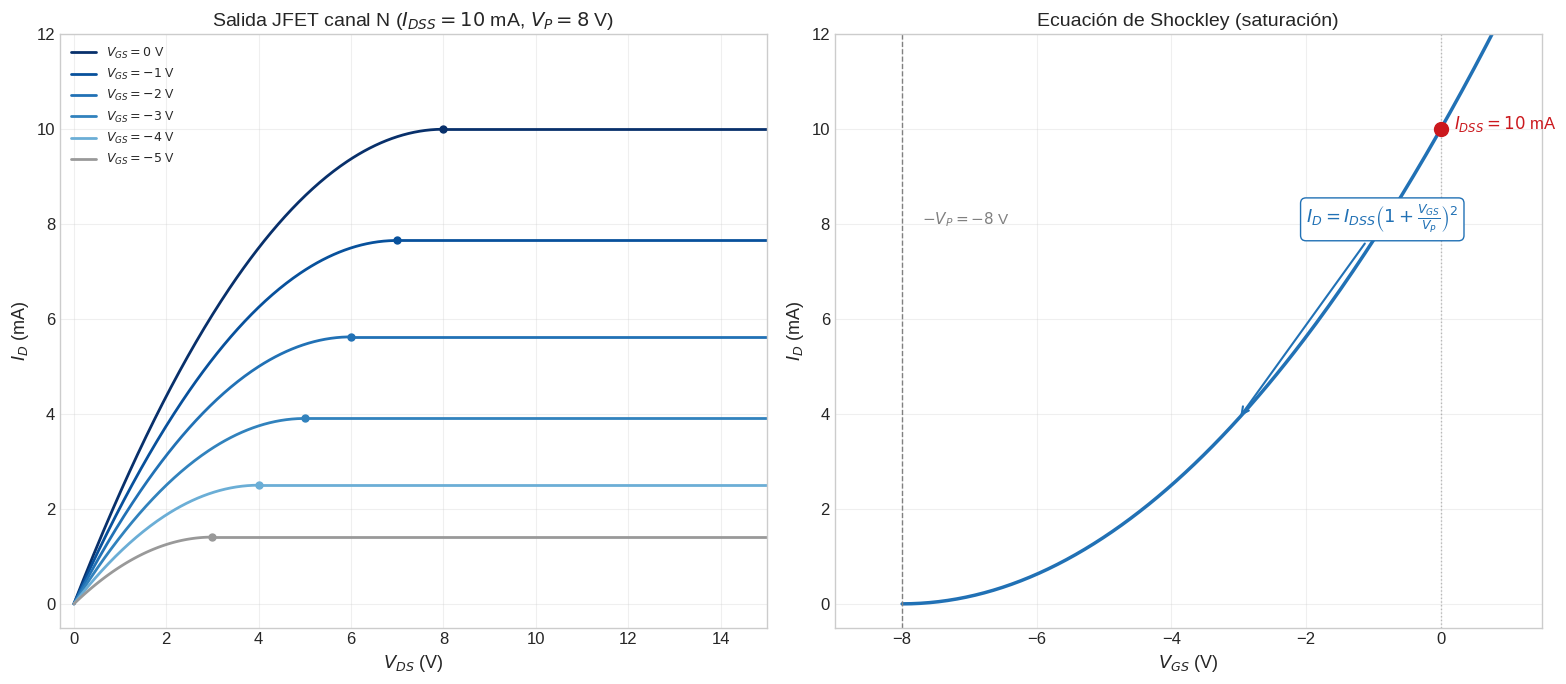

In [8]:
# Curvas características del JFET canal N
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

IDSS = 10e-3  # 10 mA
VP = 8.0       # V (pinch-off)

# Característica de salida
ax = axes[0]
VDS = np.linspace(0, 15, 500)
VGS_vals_j = [0, -1, -2, -3, -4, -5]
colores_j = ['#08306b', '#08519c', '#2171b5', '#3182bd', '#6baed6', '#999999']

for vgs, color in zip(VGS_vals_j, colores_j):
    if vgs <= -VP:
        ax.plot(VDS, np.zeros_like(VDS), color=color, lw=1.5, ls='--')
    else:
        vds_sat = vgs + VP
        id_sat = IDSS * (1 + vgs/VP)**2
        # Óhmica (simplificada)
        mask_ohm = VDS < max(vds_sat, 0.01)
        id_ohm = id_sat * (2*VDS[mask_ohm]/vds_sat - (VDS[mask_ohm]/vds_sat)**2)
        id_ohm = np.clip(id_ohm, 0, None)
        ax.plot(VDS[mask_ohm], id_ohm*1e3, color=color, lw=2)
        # Saturación
        mask_sat = VDS >= max(vds_sat, 0.01)
        ax.plot(VDS[mask_sat], np.full(mask_sat.sum(), id_sat*1e3), color=color, lw=2,
                label=rf'$V_{{GS}} = {vgs}$ V')
        ax.plot(max(vds_sat, 0), id_sat*1e3, 'o', color=color, ms=5, zorder=5)

ax.set_xlabel(r'$V_{DS}$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(rf'Salida JFET canal N ($I_{{DSS}}={IDSS*1e3:.0f}$ mA, $V_P={VP:.0f}$ V)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.3, 15); ax.set_ylim(-0.5, 12)

# Característica de saturación (Shockley)
ax = axes[1]
VGS_range = np.linspace(-VP, 1, 200)
ID_shockley = np.where(VGS_range > -VP, IDSS * (1 + VGS_range/VP)**2, 0)
ax.plot(VGS_range, ID_shockley*1e3, color=COLOR_PRINCIPAL, lw=2.5)
ax.axvline(x=-VP, color='gray', ls='--', lw=1)
ax.axvline(x=0, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(-VP+0.3, 8, rf'$-V_P = {-VP:.0f}$ V', fontsize=11, color='gray')
ax.plot(0, IDSS*1e3, 'o', color=COLOR_RECTA, ms=10, zorder=5)
ax.text(0.2, IDSS*1e3, rf'$I_{{DSS}} = {IDSS*1e3:.0f}$ mA', fontsize=12, color=COLOR_RECTA)
ax.annotate(r'$I_D = I_{DSS}\left(1+\frac{V_{GS}}{V_P}\right)^2$',
            xy=(-3, IDSS*(1-3/VP)**2*1e3), xytext=(-2, 8),
            fontsize=13, color=COLOR_PRINCIPAL,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PRINCIPAL))
ax.set_xlabel(r'$V_{GS}$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Ecuación de Shockley (saturación)')
ax.grid(True, alpha=0.3); ax.set_xlim(-9, 1.5); ax.set_ylim(-0.5, 12)
plt.tight_layout(); plt.show()

---
## 10. Polarización del JFET

### 10.1 Tipo 1: Polarización fija

Una fuente $V_1$ fija $V_{GS} = -V_1$ directamente (con $I_G = 0$, no hay caída en $R_G$).

$$I_D = I_{DSS} \left(1 + \frac{-V_1}{V_P}\right)^2 = I_{DSS} \left(1 - \frac{V_1}{V_P}\right)^2$$

$$V_{DS} = V_{CC} - R_D \cdot I_D$$

**Verificar saturación**: $V_{DS} > V_{GS} + V_P = -V_1 + V_P$

#### Ejercicio resuelto: JFET polarización fija

**Datos:** $V_1 = 2$ V, $V_{CC} = 15$ V, $R_D = 2$ k$\Omega$, $I_{DSS} = 10$ mA, $V_P = 8$ V

$$V_{GS} = -V_1 = -2\;\text{V}$$

$$I_D = 10 \times \left(1 - \frac{2}{8}\right)^2 = 10 \times 0.75^2 = 10 \times 0.5625 = 5.625\;\text{mA}$$

$$V_{DS} = 15 - 2\text{k} \times 5.625 = 15 - 11.25 = 3.75\;\text{V}$$

**Verificar:** $V_{DS} = 3.75$ V $> V_{GS} + V_P = -2 + 8 = 6$ V?

$3.75 < 6$ $\to$ **NO está en saturación.** Está en zona óhmica.

Habría que recalcular con la ecuación de zona óhmica, o bien aumentar $V_{CC}$ o reducir $R_D$ para que $V_{DS}$ sea suficiente.

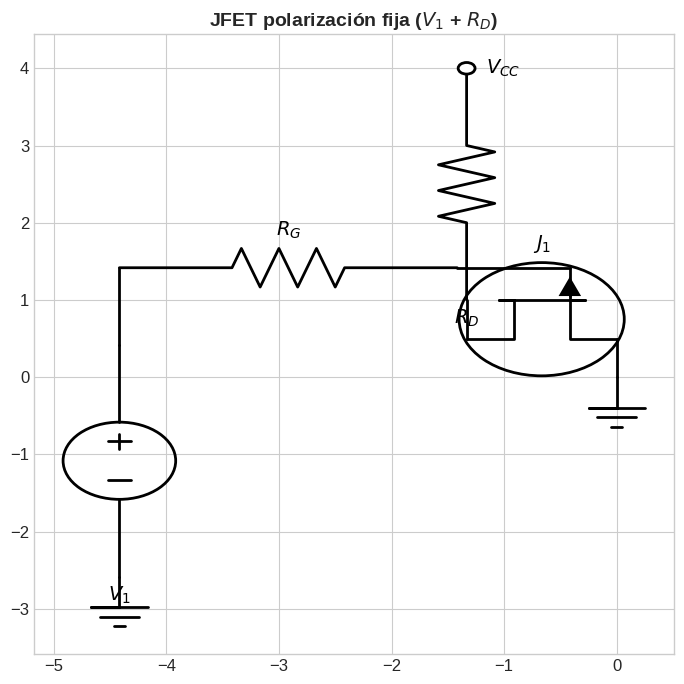

In [9]:
# Diagrama: JFET polarización fija
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'JFET polarización fija ($V_1$ + $R_D$)', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
jfet = elm.JFetN(circle=True)
d += jfet.anchor('source').label(r'$J_1$', loc='right')
j = d.elements[-1]
# RD + VCC al drenador
d += elm.Line().at(j.drain).up().length(0.5)
d += elm.Resistor().up().label(r'$R_D$', loc='left')
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
# RG + V1 a la puerta
d += elm.Line().at(j.gate).left().length(1)
d += elm.Resistor().left().label(r'$R_G$', loc='top')
d += elm.Line().down().length(1)
d += elm.SourceV().down().label(r'$V_1$', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 10.2 Tipo 2: Autopolarización ($R_S$ en fuente, $V_G = 0$)

No necesita fuente independiente para la puerta. La puerta se conecta a tierra a través de $R_G$:

$$V_G = 0 \implies V_{GS} = -R_S \cdot I_D$$

El punto de operación se obtiene gráficamente como la **intersección** de la curva de Shockley con la recta $I_D = -V_{GS}/R_S$.

**Cómo afecta $R_S$:**
- Si $R_S$ aumenta $\to$ la pendiente de la recta $-1/R_S$ disminuye $\to$ $I_D$ disminuye y $|V_{GS}|$ aumenta
- Si $R_S$ disminuye $\to$ $I_D$ se acerca a $I_{DSS}$

#### Ejercicio resuelto: JFET autopolarización

**Datos:** $V_{CC} = 15$ V, $R_D = 2$ k$\Omega$, $R_S = 500\;\Omega$, $R_G = 1$ M$\Omega$, $I_{DSS} = 10$ mA, $V_P = 8$ V

$V_G = 0$, luego $V_{GS} = -R_S \cdot I_D = -500 \cdot I_D$

Sustituyendo en Shockley: $I_D = 10 \cdot 10^{-3} \left(1 + \dfrac{-500 I_D}{8}\right)^2$

Sea $x = I_D$ en mA, $V_{GS} = -0.5x$ V:

$$x = 10 \left(1 - \frac{0.5x}{8}\right)^2 = 10 \left(1 - 0.0625x\right)^2$$

$$x = 10(1 - 0.125x + 0.00390625x^2)$$

$$x = 10 - 1.25x + 0.0390625x^2$$

$$0.0390625x^2 - 2.25x + 10 = 0$$

$$x = \frac{2.25 \pm \sqrt{5.0625 - 1.5625}}{0.078125} = \frac{2.25 \pm \sqrt{3.5}}{0.078125}$$

$$x = \frac{2.25 \pm 1.871}{0.078125}$$

$$x_1 = 52.7\;\text{mA}\;\text{(descartada, > } I_{DSS}\text{)} \qquad x_2 = 4.85\;\text{mA}$$

$$V_{GS} = -500 \times 4.85 \times 10^{-3} = -2.43\;\text{V}$$

$$V_{DS} = 15 - (2\text{k} + 0.5\text{k}) \times 4.85 = 15 - 12.13 = 2.87\;\text{V}$$

**Verificar:** $V_{DS} = 2.87$ V $\geq V_{GS} + V_P = -2.43 + 8 = 5.57$ V? NO $\to$ zona óhmica.

Para saturación necesitaríamos mayor $V_{CC}$ o menor $R_D$.

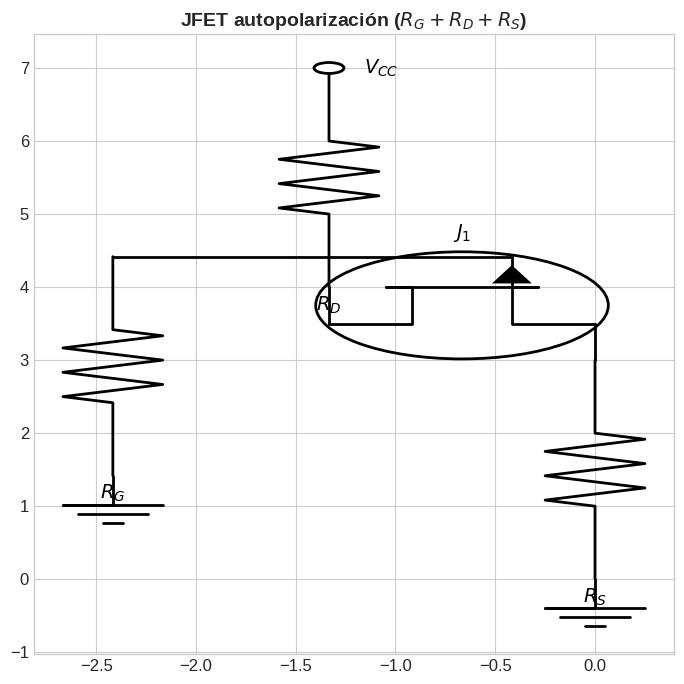

In [10]:
# Diagrama: JFET autopolarización
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'JFET autopolarización ($R_G + R_D + R_S$)', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Resistor().up().label(r'$R_S$', loc='left')
d += elm.Line().up().length(0.5)
jfet = elm.JFetN(circle=True)
d += jfet.anchor('source').label(r'$J_1$', loc='right')
j = d.elements[-1]
# RD + VCC al drenador
d += elm.Line().at(j.drain).up().length(0.5)
d += elm.Resistor().up().label(r'$R_D$', loc='left')
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
# RG de puerta a tierra
d += elm.Line().at(j.gate).left().length(2)
d += elm.Resistor().down().label(r'$R_G$', loc='left')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

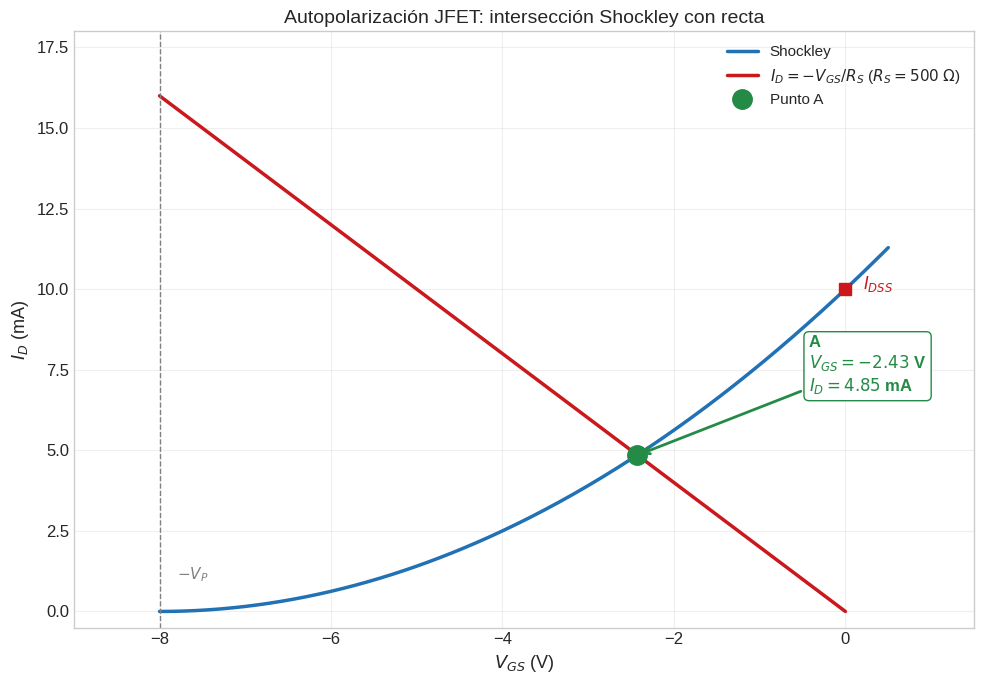

In [11]:
# Autopolarización JFET: intersección gráfica
fig, ax = plt.subplots(figsize=(10, 7))
IDSS = 10e-3; VP = 8.0; RS = 500

VGS_range = np.linspace(-VP, 0.5, 300)
ID_shockley = np.where(VGS_range > -VP, IDSS * (1 + VGS_range/VP)**2, 0)
ax.plot(VGS_range, ID_shockley*1e3, color=COLOR_PRINCIPAL, lw=2.5, label='Shockley')

# Recta de autopolarización: ID = -VGS/RS
VGS_recta = np.linspace(-8, 0, 100)
ID_recta = -VGS_recta / RS
ax.plot(VGS_recta, ID_recta*1e3, color=COLOR_RECTA, lw=2.5,
        label=rf'$I_D = -V_{{GS}}/R_S$ ($R_S={RS}\;\Omega$)')

# Punto de operación (aproximado)
ID_op = 4.85e-3; VGS_op = -RS * ID_op
ax.plot(VGS_op, ID_op*1e3, 'o', color=COLOR_PUNTO, ms=14, zorder=5, label='Punto A')
ax.annotate(f'A\n$V_{{GS}}={VGS_op:.2f}$ V\n$I_D={ID_op*1e3:.2f}$ mA',
            xy=(VGS_op, ID_op*1e3), xytext=(VGS_op+2, ID_op*1e3+2),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

ax.plot(0, IDSS*1e3, 's', color=COLOR_RECTA, ms=8)
ax.text(0.2, IDSS*1e3, rf'$I_{{DSS}}$', fontsize=12, color=COLOR_RECTA)
ax.axvline(x=-VP, color='gray', ls='--', lw=1)
ax.text(-VP+0.2, 1, rf'$-V_P$', fontsize=11, color='gray')

ax.set_xlabel(r'$V_{GS}$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Autopolarización JFET: intersección Shockley con recta')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_xlim(-9, 1.5); ax.set_ylim(-0.5, 18)
plt.tight_layout(); plt.show()

### 10.3 Tipo 3: Divisor de tensión ($R_1 + R_2 + R_D + R_S$)

Combina divisor de tensión con resistencia de fuente:

$$V_G = \frac{R_1}{R_1 + R_2} \cdot V_{CC} \qquad V_{GS} = V_G - R_S \cdot I_D$$

La recta de carga en el plano $I_D$-$V_{GS}$ tiene cortes en $(V_G, 0)$ y $(0, V_G/R_S)$.

$$I_D = I_{DSS}\left(1 + \frac{V_G - R_S I_D}{V_P}\right)^2$$

Se resuelve como ecuación cuadrática en $I_D$.

#### Ejercicio resuelto: JFET divisor de tensión

**Datos:** $V_{CC} = 20$ V, $R_1 = 200$ k$\Omega$, $R_2 = 400$ k$\Omega$, $R_D = 2$ k$\Omega$, $R_S = 1$ k$\Omega$, $I_{DSS} = 10$ mA, $V_P = 5$ V

$$V_G = \frac{200}{200+400} \times 20 = 6.67\;\text{V}$$

$$V_{GS} = 6.67 - 10^3 I_D$$

Sustituyendo en Shockley (con $I_D$ en mA, $V_{GS}$ en V):

$$x = 10\left(1 + \frac{6.67 - x}{5}\right)^2 = 10\left(\frac{11.67 - x}{5}\right)^2 = \frac{10}{25}(11.67-x)^2 = 0.4(11.67-x)^2$$

$$x = 0.4(136.19 - 23.34x + x^2)$$

$$x = 54.48 - 9.34x + 0.4x^2$$

$$0.4x^2 - 10.34x + 54.48 = 0$$

$$x = \frac{10.34 \pm \sqrt{106.9 - 87.2}}{0.8} = \frac{10.34 \pm \sqrt{19.7}}{0.8} = \frac{10.34 \pm 4.44}{0.8}$$

$$x_1 = 18.5\;\text{mA (descartada, >}I_{DSS}\text{)} \qquad x_2 = 7.38\;\text{mA}$$

$$V_{GS} = 6.67 - 7.38 = -0.71\;\text{V}$$

$$V_{DS} = 20 - (2\text{k}+1\text{k}) \times 7.38 = 20 - 22.1 = -2.1\;\text{V}$$

$V_{DS}$ negativo $\to$ los valores no son factibles con estos componentes. Habría que reducir $R_D$ o aumentar $V_{CC}$. Con $R_D = 1$ k$\Omega$:

$$V_{DS} = 20 - (1\text{k}+1\text{k}) \times 7.38 = 20 - 14.76 = 5.24\;\text{V}$$

$V_{DS} = 5.24 \geq V_{GS} + V_P = -0.71 + 5 = 4.29$ $\to$ **Saturación confirmada.**

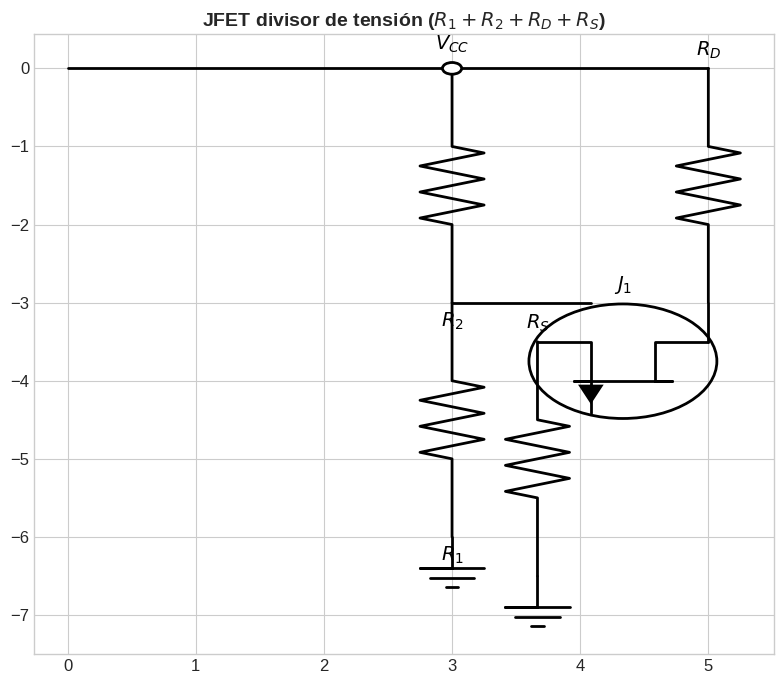

In [12]:
# Diagrama: JFET divisor de tensión
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(r'JFET divisor de tensión ($R_1 + R_2 + R_D + R_S$)', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(3)
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='top')
top = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label(r'$R_D$', loc='right')
d += elm.Line().down().length(0.5)
jfet = elm.JFetN(circle=True)
d += jfet.anchor('drain').label(r'$J_1$', loc='right')
j = d.elements[-1]
d += elm.Resistor().at(j.source).down().label(r'$R_S$', loc='right')
d += elm.Ground()
# Divisor: R2 arriba, R1 abajo
d += elm.Resistor().at(top).down().length(3).label(r'$R_2$', loc='left')
mid = d.here
d += elm.Line().right().tox(j.gate)
d += elm.Resistor().at(mid).down().length(3).label(r'$R_1$', loc='left')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

---
## 12. Catálogo completo de ejercicios FET: todos los patrones

Esta sección clasifica **todos los tipos de ejercicios** que aparecen en los exámenes de transistores FET. Para cada tipo se muestra: el circuito, las ecuaciones, cómo afecta cada componente y un ejercicio resuelto.

**Hecho clave que simplifica todo**: $I_G = 0$ siempre. Esto significa que:
- La tensión de puerta $V_G$ se obtiene directamente del circuito (sin caída en $R_G$)
- La malla de puerta es trivial
- Lo difícil es resolver la ecuación cuadrática de la corriente

### Tabla resumen de tipos

| # | Tipo | Componentes | Ecuación de $V_{GS}$ | Ec. cuadrática |
|---|------|-------------|---------------------|----------------|
| 1 | Básica MOSFET | $V_i + V_{CC}$ | $V_{GS} = V_i$ | No |
| 2 | Con $R_D$ solo | $V_{CC} + R_D$ | $V_{GS} = V_{CC} - R_D I_D$ | Sí |
| 3 | Retroalimentación | $R_G + R_D$ | $V_{GS} = V_{DS} = V_{CC} - R_D I_D$ | Sí |
| 4 | Con $R_D + R_S$ | $V_{CC} + R_D + R_S$ | $V_{GS} = V_G - R_S I_D$ | Sí |
| 5 | Divisor + $R_D + R_S$ | $R_1 + R_2 + R_D + R_S$ | $V_{GS} = V_G - R_S I_D$ | Sí |
| 6 | Canal P | Cualquiera | $V_{SG}$ en vez de $V_{GS}$ | Sí |
| 7 | Empobrecimiento | Cualquiera | $V_T < 0$ | Sí |
| 8 | JFET fija | $V_1 + R_D$ | $V_{GS} = -V_1$ | No |
| 9 | JFET autopol. | $R_G + R_D + R_S$ | $V_{GS} = -R_S I_D$ | Sí |
| 10 | JFET divisor | $R_1+R_2+R_D+R_S$ | $V_{GS} = V_G - R_S I_D$ | Sí |

### Regla general para resolver

1. Calcular $V_G$ (trivial porque $I_G = 0$)
2. Expresar $V_{GS}$ en función de $I_D$: $V_{GS} = V_G - R_S \cdot I_D$
3. Sustituir en la ecuación de saturación $\to$ ecuación cuadrática en $I_D$
4. Resolver, descartar raíz sin sentido físico
5. Calcular $V_{DS}$ con la recta de carga y verificar zona

### 12.1 Tipo 1: MOSFET polarización básica (sin resistencias)

El circuito más simple. Dos fuentes fijan $V_{GS}$ y $V_{DS}$ directamente.

$$V_{GS} = V_i \qquad V_{DS} = V_{CC} \qquad I_D = \frac{K_n}{2}(V_i - V_T)^2$$

**No hay ecuación cuadrática**: todo es directo.

**Cómo afectan los parámetros:**
- **$V_i$ controla $I_D$** cuadráticamente: duplicar $(V_i - V_T)$ cuadruplica $I_D$
- **$V_{CC}$** solo afecta a $V_{DS}$: la recta de carga es vertical
- Si $V_i < V_T$: transistor en **corte**, $I_D = 0$
- Si $V_i$ es muy grande: riesgo de superar $V_{GS_{max}}$

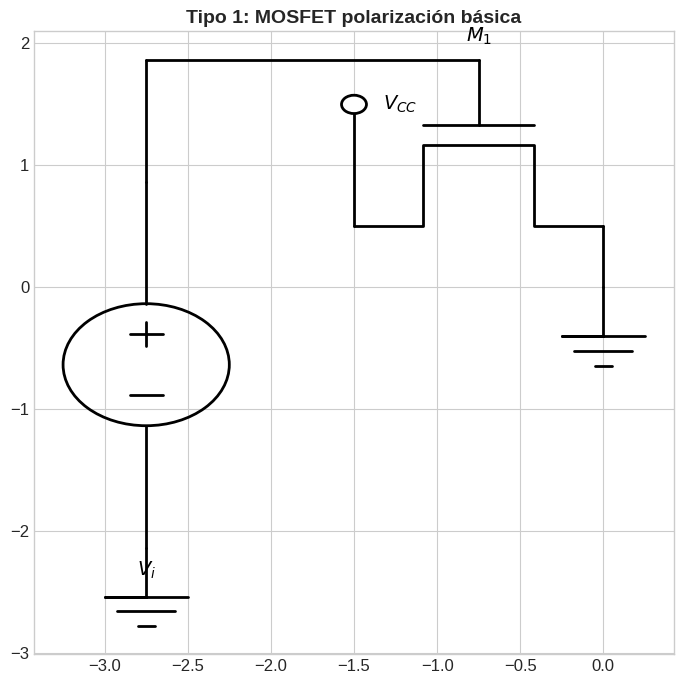

In [13]:
# Diagrama: Tipo 1 - MOSFET polarización básica (sin resistencias)
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 1: MOSFET polarización básica', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
nmos = elm.NFet(circle=True)
d += nmos.anchor('source').label(r'$M_1$', loc='right')
m = d.elements[-1]
# VCC al drenador
d += elm.Line().at(m.drain).up().length(1)
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
# Vi a la puerta
d += elm.Line().at(m.gate).left().length(2)
d += elm.Line().down().length(1)
d += elm.SourceV().down().label(r'$V_i$', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 12.2 Tipo 2: MOSFET con $R_D$ y fuente en puerta

Una fuente $V_i$ fija $V_{GS} = V_i$, y $R_D$ aparece en la malla de drenador.

$$V_{GS} = V_i \qquad I_D = \frac{K_n}{2}(V_i - V_T)^2 \qquad V_{DS} = V_{CC} - R_D \cdot I_D$$

**Tampoco hay cuadrática** porque $V_{GS}$ es independiente de $I_D$.

**Cómo afecta $R_D$:**
- **$R_D$ NO afecta a $I_D$** (porque $V_{GS}$ no depende de $R_D$)
- **$R_D$ sí afecta a $V_{DS}$**: mayor $R_D$ $\to$ menor $V_{DS}$ $\to$ puede pasar de saturación a zona óhmica
- **Frontera**: el transistor sale de saturación cuando $V_{DS} < V_{GS} - V_T$, es decir:
$$V_{CC} - R_D \cdot I_D < V_i - V_T \implies R_D > \frac{V_{CC} - V_i + V_T}{I_D}$$

#### Ejercicio resuelto: MOSFET con $R_D$

**Datos:** $V_i = 5$ V, $V_{CC} = 12$ V, $R_D = 1$ k$\Omega$, $K_n = 4$ mA/V$^2$, $V_T = 2$ V

$$V_{GS} = V_i = 5\;\text{V} > V_T = 2\;\text{V} \to \text{conduce}$$

$$I_D = \frac{4 \times 10^{-3}}{2}(5-2)^2 = 2 \times 10^{-3} \times 9 = 18\;\text{mA}$$

$$V_{DS} = 12 - 1\text{k} \times 18 = 12 - 18 = -6\;\text{V}$$

$V_{DS}$ negativo $\to$ **no está en saturación**. El transistor está en **zona óhmica**.

Recalculando con la ecuación óhmica (o simplemente con $R_D$ menor, por ejemplo $R_D = 500\;\Omega$):

$$V_{DS} = 12 - 500 \times 18\text{mA} = 12 - 9 = 3\;\text{V}$$

$V_{DS} = 3$ V $\geq V_{GS} - V_T = 3$ V $\to$ **Justo en la frontera saturación/óhmica.**

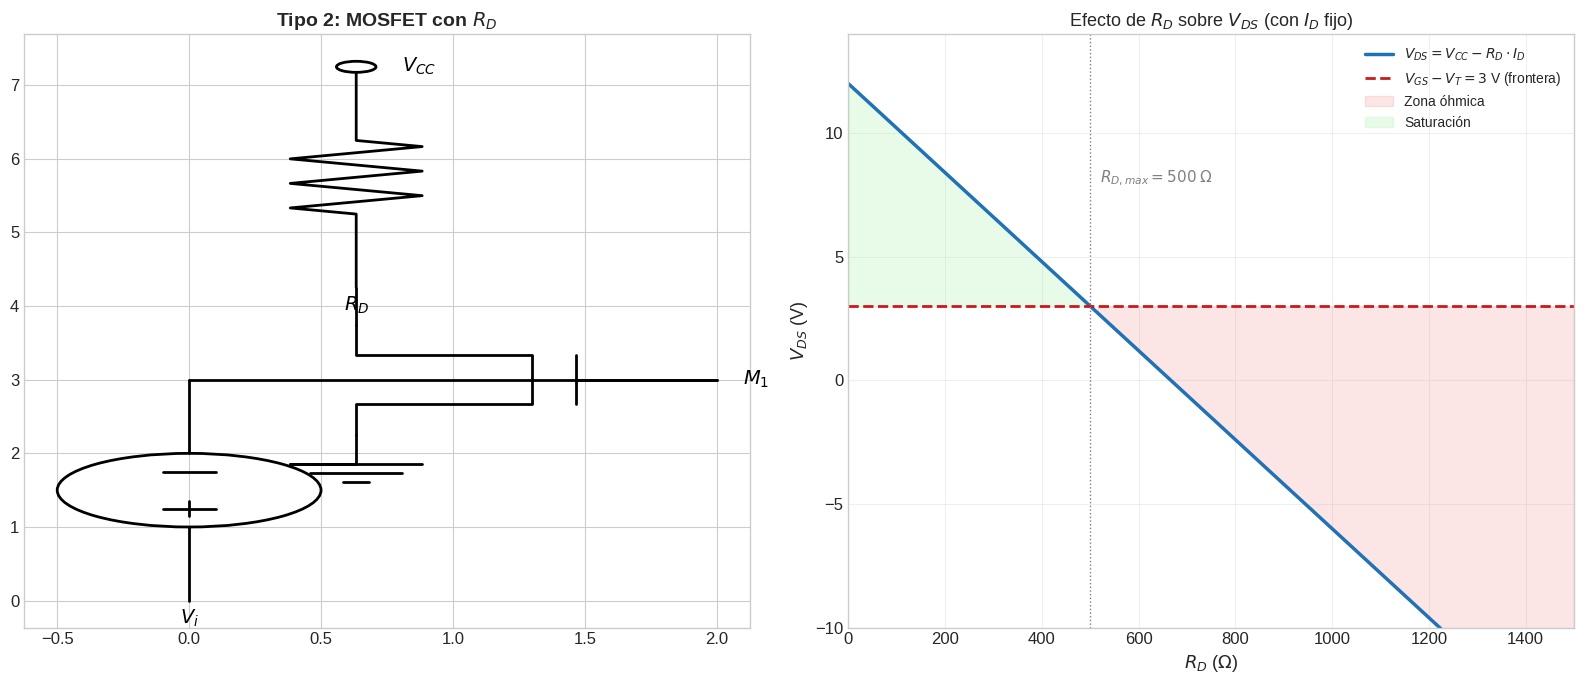

In [14]:
# Tipo 2: Diagrama y efecto de RD sobre VDS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Diagrama
ax = axes[0]
ax.set_title(r'Tipo 2: MOSFET con $R_D$', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label('$V_i$', loc='left').reverse()
d += elm.Line().right().length(2)
nmos = elm.NFet(circle=True)
d += nmos.anchor('gate').label('$M_1$', loc='right')
m = d.elements[-1]
d += elm.Ground().at(m.source)
d += elm.Line().at(m.drain).up().length(0.5)
d += elm.Resistor().up().label('$R_D$', loc='left')
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
d.draw()

# Efecto de RD sobre VDS
ax = axes[1]
ax.set_title(r'Efecto de $R_D$ sobre $V_{DS}$ (con $I_D$ fijo)', fontsize=13)
RD_vals = np.linspace(0, 1500, 100)
ID_fijo = 18e-3  # mA
Vcc = 12
VDS_vals = Vcc - RD_vals * ID_fijo
VGS_VT = 3  # V_i - V_T

ax.plot(RD_vals, VDS_vals, color=COLOR_PRINCIPAL, lw=2.5, label=r'$V_{DS} = V_{CC} - R_D \cdot I_D$')
ax.axhline(y=VGS_VT, color=COLOR_RECTA, ls='--', lw=2, label=rf'$V_{{GS}} - V_T = {VGS_VT}$ V (frontera)')
ax.fill_between(RD_vals, VDS_vals, VGS_VT, where=VDS_vals < VGS_VT,
                alpha=0.2, color='lightcoral', label=r'Zona óhmica')
ax.fill_between(RD_vals, VDS_vals, VGS_VT, where=VDS_vals >= VGS_VT,
                alpha=0.2, color='lightgreen', label='Saturación')

RD_lim = (Vcc - VGS_VT) / ID_fijo
ax.axvline(x=RD_lim, color='gray', ls=':', lw=1)
ax.text(RD_lim + 20, 8, rf'$R_{{D,max}} = {RD_lim:.0f}\;\Omega$', fontsize=11, color='gray')

ax.set_xlabel(r'$R_D$ ($\Omega$)'); ax.set_ylabel(r'$V_{DS}$ (V)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1500); ax.set_ylim(-10, 14)
plt.tight_layout(); plt.show()

### 12.3 Tipo 3: Retroalimentación ($R_G$ de D a G)

$R_G$ conecta drenador con puerta. Como $I_G = 0$: $V_{GS} = V_{DS}$.

$$V_{DS} = V_{CC} - R_D \cdot I_D \qquad I_D = \frac{K_n}{2}(V_{DS} - V_T)^2$$

Sustituyendo: **ecuación cuadrática** en $V_{DS}$.

**Cómo afectan los parámetros:**
- **$R_D$ aumenta** $\to$ $V_{DS}$ disminuye $\to$ $V_{GS}$ disminuye $\to$ $I_D$ disminuye (autoestabilización)
- **$V_{CC}$ aumenta** $\to$ $V_{DS}$ aumenta $\to$ más $I_D$
- **$R_G$** no afecta al punto de operación (porque $I_G = 0$ y la caída es nula). Solo sirve para aislar la entrada.
- **$K_n$ mayor** $\to$ más $I_D$ para el mismo $V_{GS}$

**Truco**: la ecuación se puede escribir como $R_D \cdot \frac{K_n}{2}(V_{DS}-V_T)^2 + V_{DS} - V_{CC} = 0$

### 12.4 Tipo 4: MOSFET con $R_D + R_S$ y fuente en puerta

La resistencia $R_S$ en la fuente crea una caída $V_S = R_S \cdot I_D$, lo que reduce $V_{GS}$:

$$V_G = V_i \qquad V_{GS} = V_i - R_S \cdot I_D$$

$$I_D = \frac{K_n}{2}(V_i - R_S I_D - V_T)^2$$

Esto produce una **ecuación cuadrática** en $I_D$.

$$V_{DS} = V_{CC} - (R_D + R_S) \cdot I_D$$

**Cómo afecta $R_S$:**
- **$R_S$ estabiliza $I_D$**: si $I_D$ sube $\to$ $V_S = R_S I_D$ sube $\to$ $V_{GS}$ baja $\to$ $I_D$ se corrige
- Mismo mecanismo de realimentación negativa que en el BJT
- **$R_S$ grande**: menor $I_D$, más estable, menos $V_{DS}$ disponible
- **$R_S = 0$**: vuelve al Tipo 2 (sin estabilización)

**Error frecuente**: olvidar que $V_{DS} = V_{CC} - (R_D + R_S) \cdot I_D$, no solo $R_D \cdot I_D$

#### Ejercicio resuelto: MOSFET con $R_D + R_S$

**Datos:** $V_i = 6$ V, $V_{CC} = 15$ V, $R_D = 2$ k$\Omega$, $R_S = 1$ k$\Omega$, $K_n = 2$ mA/V$^2$, $V_T = 2$ V

**Paso 1-2:** Suponer saturación. $V_{GS} = V_i - R_S \cdot I_D = 6 - 10^3 I_D$

**Paso 3-4:** Sea $x = I_D$ en mA:

$$x = \frac{2 \times 10^{-3}}{2}(6 - x - 2)^2 = 10^{-3}(4-x)^2$$

$$x = 10^{-3}(16 - 8x + x^2) \implies 1000x = 16 - 8x + x^2$$

Ojo, las unidades: $I_D$ en A, $R_S$ en $\Omega$:

$$I_D = 10^{-3}(6 - 10^3 I_D - 2)^2 = 10^{-3}(4 - 10^3 I_D)^2$$

Sea $y = I_D$ en mA:

$$y \times 10^{-3} = 10^{-3}(4 - y)^2 \implies y = (4-y)^2 = 16 - 8y + y^2$$

$$y^2 - 9y + 16 = 0$$

$$y = \frac{9 \pm \sqrt{81 - 64}}{2} = \frac{9 \pm \sqrt{17}}{2} = \frac{9 \pm 4.12}{2}$$

$$y_1 = 6.56\;\text{mA} \qquad y_2 = 2.44\;\text{mA}$$

Para $y_2 = 2.44$ mA: $V_{GS} = 6 - 2.44 = 3.56$ V $> V_T$ OK

$$V_{DS} = 15 - (2\text{k}+1\text{k}) \times 2.44 = 15 - 7.32 = 7.68\;\text{V}$$

$V_{DS} = 7.68 \geq V_{GS} - V_T = 3.56 - 2 = 1.56$ $\to$ **Saturación OK.**

Para $y_1 = 6.56$ mA: $V_{GS} = 6 - 6.56 = -0.56$ V $< V_T$ $\to$ **Corte (descartada).**

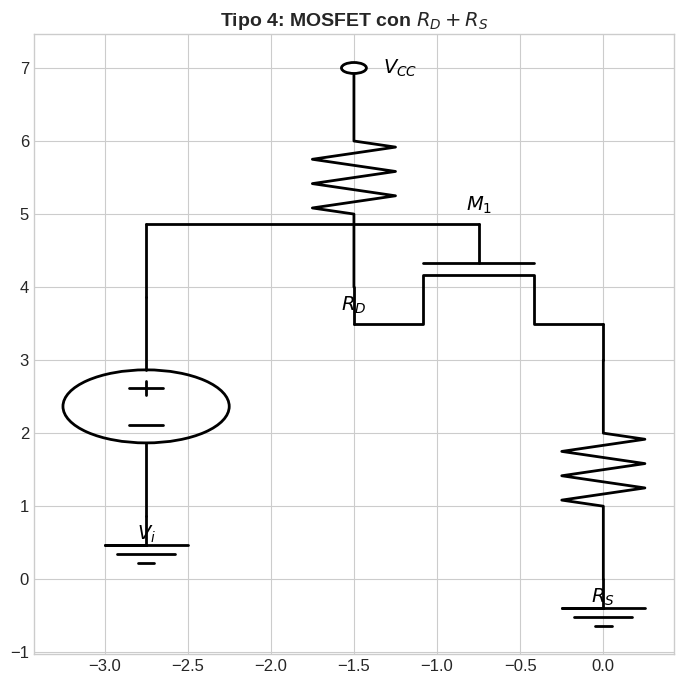

In [15]:
# Tipo 4: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 4: MOSFET con $R_D + R_S$', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Resistor().up().label('$R_S$', loc='left')
d += elm.Line().up().length(0.5)
nmos = elm.NFet(circle=True)
d += nmos.anchor('source').label('$M_1$', loc='right')
m = d.elements[-1]
d += elm.Line().at(m.drain).up().length(0.5)
d += elm.Resistor().up().label('$R_D$', loc='left')
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
# Puerta
d += elm.Line().at(m.gate).left().length(2)
d += elm.Line().down().length(1)
d += elm.SourceV().down().label('$V_i$', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 12.5 Tipo 5: Divisor de tensión + $R_D + R_S$ (el más completo)

El circuito **más estable** para MOSFET. Ya resuelto en la sección 7.3. Aquí se resumen los efectos de cada componente:

$$V_G = \frac{R_1}{R_1+R_2} V_{CC} \qquad V_{GS} = V_G - R_S I_D \qquad V_{DS} = V_{CC} - (R_D+R_S)I_D$$

**Cómo afecta cada resistencia:**

| Componente | Efecto al aumentar |
|---|---|
| $R_1/(R_1+R_2)$ | $V_G$ sube $\to$ $V_{GS}$ sube $\to$ $I_D$ sube |
| $R_S$ | Estabiliza $I_D$ (realimentación negativa). Pendiente de la recta de carga en plano $I_D$-$V_{GS}$ disminuye |
| $R_D$ | Solo afecta a $V_{DS}$: mayor $R_D$ $\to$ menor $V_{DS}$ $\to$ riesgo de salir de saturación |
| $V_{CC}$ | $V_G$ sube (proporcionalmente), $V_{DS}$ sube |
| $K_n$ | Más $I_D$ para mismo $V_{GS}$. Cambia la curvatura de la parábola |
| $V_T$ | Mayor $V_T$ $\to$ se necesita más $V_{GS}$ para conducir $\to$ menos $I_D$ |

**A diferencia del BJT**: el divisor no tiene carga ($I_G = 0$), por lo que **no se necesita Thévenin**. $V_G$ se calcula directamente.

### 12.6 Tipo 6: MOSFET canal P

Para canal P, las reglas cambian respecto al canal N:

| Concepto | Canal N | Canal P |
|---|---|---|
| Tensión de control | $V_{GS}$ | $V_{SG}$ (invertida) |
| Tensión de salida | $V_{DS}$ | $V_{SD}$ (invertida) |
| Condición conducción | $V_{GS} > V_T$ | $V_{SG} > V_T$ |
| Ec. saturación | $I_D = \frac{K_n}{2}(V_{GS}-V_T)^2$ | $I_D = \frac{K_p}{2}(V_{SG}-V_T)^2$ |
| Condición saturación | $V_{DS} \geq V_{GS} - V_T$ | $V_{SD} \geq V_{SG} - V_T$ |
| $V_T$ (enriquecimiento) | Positivo | Positivo (con $V_{SG}$) |
| $V_{CC}$ se conecta a | Drenador (arriba) | Fuente (arriba) |

**Truco**: con las referencias $V_{SG}$ y $V_{SD}$, las ecuaciones del canal P son **idénticas** a las del canal N. Solo cambia la posición del transistor en el circuito.

#### Ejercicio resuelto: MOSFET canal P con divisor

**Datos:** $V_{CC} = 10$ V, $R_1 = 100$ k$\Omega$ (abajo), $R_2 = 200$ k$\Omega$ (arriba), $R_D = 1.5$ k$\Omega$, $R_S = 500\;\Omega$, $K_p = 3$ mA/V$^2$, $V_T = 2$ V

**Paso 1:** $V_G = \dfrac{R_1}{R_1+R_2} V_{CC} = \dfrac{100}{300} \times 10 = 3.33$ V

**Paso 2:** Para canal P: $V_{SG} = V_S - V_G$. La fuente está conectada a $V_{CC}$ a través de $R_S$:

$$V_S = V_{CC} - R_S \cdot I_D = 10 - 500 I_D$$

$$V_{SG} = V_S - V_G = 10 - 500 I_D - 3.33 = 6.67 - 500 I_D$$

**Paso 3-4:** Suponer saturación:

$$I_D = \frac{K_p}{2}(V_{SG}-V_T)^2 = \frac{3\times10^{-3}}{2}(6.67 - 500 I_D - 2)^2$$

Sea $x = I_D$ en mA:

$$x = 1.5 \times 10^{-3}(4.67 - 0.5x)^2 \times 10^{6}$$

Esto no simplifica bien. Usemos $x$ en mA y $V_{SG}$ en V:

$$x = 1.5(4.67 - 0.5x)^2 = 1.5(21.81 - 4.67x + 0.25x^2)$$

$$x = 32.72 - 7.005x + 0.375x^2$$

$$0.375x^2 - 8.005x + 32.72 = 0$$

$$x = \frac{8.005 \pm \sqrt{64.08 - 49.08}}{0.75} = \frac{8.005 \pm \sqrt{15.00}}{0.75} = \frac{8.005 \pm 3.873}{0.75}$$

$$x_1 = 15.84\;\text{mA} \qquad x_2 = 5.51\;\text{mA}$$

Para $x_2 = 5.51$ mA: $V_{SG} = 6.67 - 0.5 \times 5.51 = 3.92$ V $> V_T$ OK

$$V_{SD} = V_{CC} - (R_S + R_D) \cdot I_D = 10 - 2\text{k} \times 5.51 = -1.02\;\text{V}$$

$V_{SD}$ negativo $\to$ **no es factible**. Necesitamos menor $R_D$.

Con $R_D = 1$ k$\Omega$: $V_{SD} = 10 - 1.5\text{k} \times 5.51 = 1.74$ V.

$V_{SD} = 1.74 \geq V_{SG} - V_T = 3.92 - 2 = 1.92$ V? NO $\to$ zona óhmica (por poco).

Con $R_D = 500\;\Omega$: $V_{SD} = 10 - 1\text{k} \times 5.51 = 4.49$ V $\geq 1.92$ $\to$ **Saturación OK.**

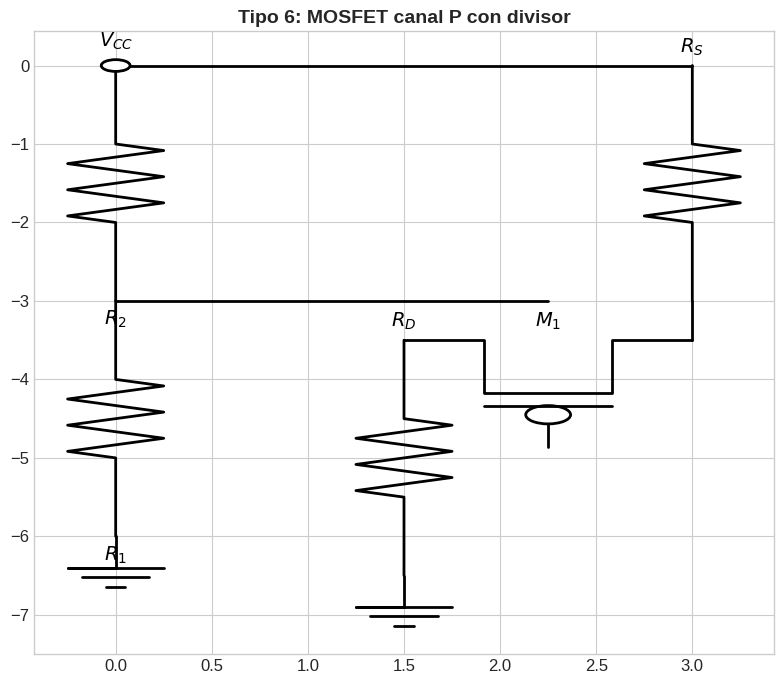

In [16]:
# Tipo 6: MOSFET canal P con divisor
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Tipo 6: MOSFET canal P con divisor', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}$', loc='top')
top = d.here
# R2 (arriba) y R1 (abajo)
d += elm.Resistor().down().length(3).label('$R_2$', loc='left')
mid = d.here
d += elm.Resistor().down().length(3).label('$R_1$', loc='left')
d += elm.Ground()
# RS desde VCC al source del PMOS
d += elm.Line().at(top).right().length(3)
d += elm.Resistor().down().label('$R_S$', loc='right')
d += elm.Line().down().length(0.5)
pmos = elm.PFet(circle=True)
d += pmos.anchor('source').label('$M_1$', loc='right')
m = d.elements[-1]
# Gate al punto medio
d += elm.Line().at(mid).right().tox(m.gate)
# RD desde drain a GND
d += elm.Resistor().at(m.drain).down().label('$R_D$', loc='right')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 12.7 Tipo 7: MOSFET de empobrecimiento

Los MOSFET de empobrecimiento tienen $V_T < 0$ (canal N) o $V_T > 0$ (canal P con $V_{SG}$). Esto significa que **conducen a $V_{GS} = 0$**.

**Diferencias con enriquecimiento:**
- A $V_{GS} = 0$: $I_D = \frac{K_n}{2}V_T^2 \neq 0$ (ya conduce)
- Se puede apagar aplicando $V_{GS} < V_T$ (tensión negativa para canal N)
- Las ecuaciones son **idénticas**, solo cambia el signo de $V_T$
- Se comportan como un **JFET con aislamiento de óxido**

#### Ejercicio resuelto: MOSFET empobrecimiento

**Datos:** $V_{CC} = 12$ V, $R_D = 2$ k$\Omega$, puerta a tierra ($V_{GS} = 0$), $K_n = 1$ mA/V$^2$, $V_T = -3$ V

$$V_{GS} = 0\;\text{V} > V_T = -3\;\text{V} \to \text{conduce}$$

$$I_D = \frac{K_n}{2}(V_{GS}-V_T)^2 = \frac{10^{-3}}{2}(0-(-3))^2 = 0.5 \times 10^{-3} \times 9 = 4.5\;\text{mA}$$

$$V_{DS} = 12 - 2\text{k} \times 4.5 = 3\;\text{V}$$

$V_{DS} = 3 \geq V_{GS} - V_T = 0 + 3 = 3$ V $\to$ **Justo en la frontera. Saturación.**

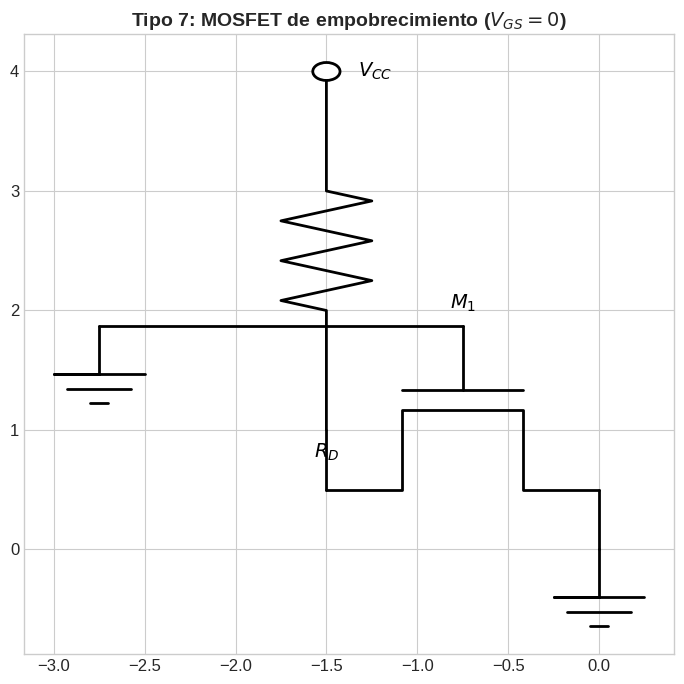

In [17]:
# Diagrama: Tipo 7 - MOSFET de empobrecimiento
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 7: MOSFET de empobrecimiento ($V_{GS} = 0$)', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
nmos = elm.NFet(circle=True)
d += nmos.anchor('source').label(r'$M_1$', loc='right')
m = d.elements[-1]
# RD + VCC al drenador
d += elm.Line().at(m.drain).up().length(0.5)
d += elm.Resistor().up().label(r'$R_D$', loc='left')
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
# Puerta conectada a tierra (VGS = 0)
d += elm.Line().at(m.gate).left().length(2)
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 12.8 Tipo especial: Determinar la zona de funcionamiento

Un ejercicio frecuente es: dado un MOSFET con ciertos valores de $V_{GS}$, $V_{DS}$ y $V_T$, **determinar en qué zona está**.

**Algoritmo:**

```
1. ¿V_GS > V_T?
   NO → CORTE (I_D = 0)
   SÍ → conduce. Ir a paso 2.

2. ¿V_DS ≥ V_GS - V_T?
   SÍ → SATURACIÓN
   NO → ZONA ÓHMICA
```

#### Ejercicio: Identificar zonas

| $V_{GS}$ | $V_T$ | $V_{DS}$ | $V_{GS}>V_T$? | $V_{DS}\geq V_{GS}-V_T$? | **Zona** |
|-----------|-------|----------|---------------|--------------------------|----------|
| 3 V | 2 V | 5 V | Sí | 5 $\geq$ 1: Sí | **Saturación** |
| 1 V | 2 V | 5 V | No | - | **Corte** |
| 4 V | 1 V | 2 V | Sí | 2 $\geq$ 3: No | **Óhmica** |
| 5 V | 2 V | 3 V | Sí | 3 $\geq$ 3: Sí | **Frontera sat/óhm** |
| -1 V | -3 V | 4 V | Sí ($-1>-3$) | 4 $\geq$ 2: Sí | **Sat. (empob.)** |

### 12.9 Tipo especial: Calcular $K_n$ desde el punto de operación

Si te dan $I_D$ y $V_{GS}$ en saturación, puedes obtener $K_n$:

$$K_n = \frac{2 I_D}{(V_{GS} - V_T)^2}$$

Si te dan $I_D$ para dos valores de $V_{GS}$, puedes obtener $K_n$ y $V_T$:

$$\frac{I_{D1}}{I_{D2}} = \frac{(V_{GS1} - V_T)^2}{(V_{GS2} - V_T)^2} \implies \sqrt{\frac{I_{D1}}{I_{D2}}} = \frac{V_{GS1} - V_T}{V_{GS2} - V_T}$$

#### Ejercicio: Encontrar $K_n$ y $V_T$

**Datos:** $I_{D1} = 2$ mA a $V_{GS1} = 4$ V; $I_{D2} = 8$ mA a $V_{GS2} = 6$ V

$$\sqrt{\frac{2}{8}} = \sqrt{0.25} = 0.5 = \frac{4 - V_T}{6 - V_T}$$

$$0.5(6 - V_T) = 4 - V_T \implies 3 - 0.5V_T = 4 - V_T$$

$$0.5 V_T = 1 \implies V_T = 2\;\text{V}$$

$$K_n = \frac{2 \times 2 \times 10^{-3}}{(4-2)^2} = \frac{4 \times 10^{-3}}{4} = 1\;\text{mA/V}^2$$

### 12.10 Resumen: fórmulas por tipo de circuito FET

#### MOSFET

| Tipo | $V_{GS}$ | Cuadrática? | Clave |
|------|----------|-------------|-------|
| 1. Básica | $= V_i$ | No | Directo |
| 2. Con $R_D$ | $= V_i$ | No | $R_D$ no afecta a $I_D$ |
| 3. Retroalim. | $= V_{CC} - R_D I_D$ | Sí | $V_{GS} = V_{DS}$ |
| 4. Con $R_S$ | $= V_i - R_S I_D$ | Sí | $R_S$ estabiliza |
| 5. Divisor | $= V_G - R_S I_D$ | Sí | No hace falta Thévenin |
| 6. Canal P | $V_{SG} = V_S - V_G$ | Sí | Invertir referencias |
| 7. Empob. | Igual que enriq. | Depende | $V_T < 0$, conduce a $V_{GS}=0$ |

#### JFET

| Tipo | $V_{GS}$ | Cuadrática? | Clave |
|------|----------|-------------|-------|
| 8. Fija | $= -V_1$ | No | Directo con Shockley |
| 9. Autopol. | $= -R_S I_D$ | Sí | Intersección gráfica |
| 10. Divisor | $= V_G - R_S I_D$ | Sí | Recta corta en $(V_G, 0)$ |

**Patrón universal**: siempre que $R_S$ aparece, hay ecuación cuadrática, porque $V_{GS}$ depende de $I_D$.

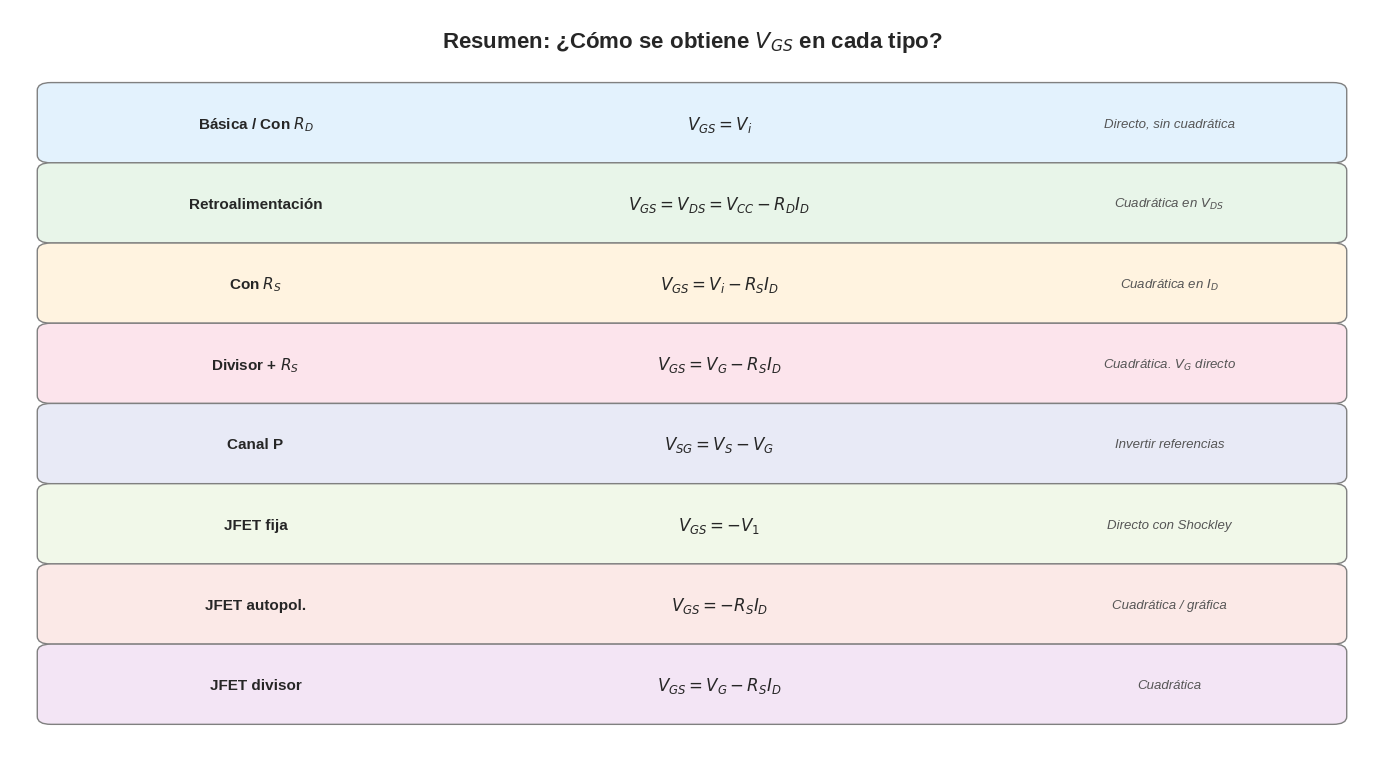

In [18]:
# Resumen visual: cómo se obtiene VGS en cada tipo
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off'); ax.set_xlim(0, 10); ax.set_ylim(0, 10)

ax.text(5, 9.5, r'Resumen: ¿Cómo se obtiene $V_{GS}$ en cada tipo?', fontsize=16,
        fontweight='bold', ha='center')

datos = [
    ('Básica / Con $R_D$', r'$V_{GS} = V_i$', 'Directo, sin cuadrática', '#e3f2fd'),
    ('Retroalimentación', r'$V_{GS} = V_{DS} = V_{CC} - R_D I_D$', 'Cuadrática en $V_{DS}$', '#e8f5e9'),
    ('Con $R_S$', r'$V_{GS} = V_i - R_S I_D$', 'Cuadrática en $I_D$', '#fff3e0'),
    ('Divisor + $R_S$', r'$V_{GS} = V_G - R_S I_D$', 'Cuadrática. $V_G$ directo', '#fce4ec'),
    ('Canal P', r'$V_{SG} = V_S - V_G$', 'Invertir referencias', '#e8eaf6'),
    ('JFET fija', r'$V_{GS} = -V_1$', 'Directo con Shockley', '#f1f8e9'),
    ('JFET autopol.', r'$V_{GS} = -R_S I_D$', 'Cuadrática / gráfica', '#fbe9e7'),
    ('JFET divisor', r'$V_{GS} = V_G - R_S I_D$', 'Cuadrática', '#f3e5f5'),
]

for i, (tipo, formula, nota, color) in enumerate(datos):
    y = 8.5 - i * 1.05
    ax.add_patch(FancyBboxPatch((0.3, y-0.4), 9.4, 0.85,
                 boxstyle='round,pad=0.1', facecolor=color, edgecolor='gray'))
    ax.text(1.8, y, tipo, fontsize=11, ha='center', va='center', fontweight='bold')
    ax.text(5.2, y, formula, fontsize=12, ha='center', va='center')
    ax.text(8.5, y, nota, fontsize=9.5, ha='center', va='center', style='italic', color='#555')

plt.tight_layout(); plt.show()

---
## 11. Resumen comparativo: MOSFET vs JFET

| Característica | MOSFET | JFET |
|---|---|---|
| Estructura | Metal-Óxido-Semiconductor | Unión pn |
| Control de puerta | Por campo eléctrico (capacitivo) | Por unión pn (inversa) |
| $I_G$ | $= 0$ (siempre) | $= 0$ (en operación normal) |
| Tipos | 4 (N/P, enriq./empob.) | 2 (N/P) |
| A $V_{GS}=0$ | Enriq: apagado. Empob: encendido | Siempre encendido ($I_D = I_{DSS}$) |
| Ec. saturación | $I_D = \frac{K_n}{2}(V_{GS}-V_T)^2$ | $I_D = I_{DSS}(1+V_{GS}/V_P)^2$ |
| Relación | $K_n$, $V_T$ | $K = 2I_{DSS}/V_P^2$, $V_T = -V_P$ |

### Fórmulas clave

| Fórmula | Uso |
|---------|-----|
| $I_D = \frac{K_n}{2}(V_{GS}-V_T)^2$ | MOSFET en saturación |
| $I_D = I_{DSS}(1 + V_{GS}/V_P)^2$ | JFET en saturación (Shockley) |
| $V_{DS} \geq V_{GS} - V_T$ | Condición de saturación MOSFET |
| $V_{DS} \geq V_{GS} + V_P$ | Condición de saturación JFET |
| $I_G = 0$ | Siempre (simplifica malla de puerta) |
| $R_{DS} = 1/[K_n(V_{GS}-V_T)]$ | MOSFET como resistencia (zona óhmica) |
| $V_{GS} = V_G - R_S \cdot I_D$ | Malla de puerta con $R_S$ |